# Avance 2: Ingeniería de características

# **Procesamiento de Lenguaje Natural**


## Maestría en Inteligencia Artificial Aplicada
### Tecnológico de Monterrey

* **Nombres y matrículas**
    * Sarmiento Cervantes Jacqueline: A01795863
    * Mayoral Terán Alexandro: A01795899
* **Número de equipo: 8**

En este avance se transforma el corpus regulatorio, los formularios existentes y sus catálogos asociados en representaciones útiles para recuperación semántica y generación posterior de formularios.

La ingeniería de características se aborda en tres niveles:

1. Características estructurales: documento, sección, campo, catálogo.
2. Características textuales: longitud, términos relevantes, presencia de artículos, presencia de tablas.
3. Representaciones vectoriales: TF-IDF y embeddings semánticos.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import re
import os
import sys
import json
import warnings
import time
import requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity


sns.set_theme(style='whitegrid', palette='Dark2')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_colwidth', 120)


warnings.filterwarnings("ignore")

In [3]:
from langchain_text_splitters import MarkdownHeaderTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_core.documents import Document

In [4]:
NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name != 'notebooks':
    NOTEBOOK_DIR = NOTEBOOK_DIR / 'notebooks'
PROJECT_ROOT = NOTEBOOK_DIR.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_RAW = PROJECT_ROOT / "data" / "01_raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "02_interim"
DATA_OUTPUT = PROJECT_ROOT / "data" / "03_output"

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_INTERIM.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 5)

## Conversión de PDFs a Mardown a través de la herramienta Blazedocs

Los documentos regulatorios originales se encuentran en formato PDF. Para facilitar su análisis dentro de un flujo de NLP, se convierten a Markdown, ya que este formato conserva mejor la estructura lógica del documento, incluyendo encabezados, párrafos y tablas.

En este proyecto se utiliza BlazeDocs para la conversión de PDFs a Markdown mediante la API de la aplicación, utilizando el siguiente código:

In [5]:
import requests

BLAZEDOCS_API_URL = "https://blazedocs.io/api/v1/convert"

# Folder con pdfs originales
PDF_INPUT_DIR = DATA_RAW / "pdfs"

# Folder con formularios originales
FORM_INPUT_DIR = DATA_RAW / "formularios"

# Folder con catálogos originales
CAT_INPUT_DIR = DATA_RAW / "catalogos"

# Folder donde se guardan archivos markdown
MARKDOWN_OUTPUT_DIR = DATA_INTERIM / "markdown"

# Folder donde se guardan dataframes
DF_OUTPUT_DIR = DATA_INTERIM / "dataframes"

#Folder base datos vectorizada chroma
CHROMA_PERSIST_DIR = DATA_OUTPUT / "chroma_db"

# Crear folder si no existe
PDF_INPUT_DIR.mkdir(parents=True, exist_ok=True)
FORM_INPUT_DIR.mkdir(parents=True, exist_ok=True)
CAT_INPUT_DIR.mkdir(parents=True, exist_ok=True)
MARKDOWN_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DF_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHROMA_PERSIST_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"PDF input folder: {PDF_INPUT_DIR}")
print(f"Forms input folder: {FORM_INPUT_DIR}")
print(f"Catalogs input folder: {CAT_INPUT_DIR}")

print(f"Markdown output folder: {MARKDOWN_OUTPUT_DIR}")
print(f"Dataframes output folder: {DF_OUTPUT_DIR}")
print(f"CHROMA output folder: {CHROMA_PERSIST_DIR}")

Project root: c:\bluepill5\Hack\Maestria\ProyectoIntegrador\proyecto_disf_npl
PDF input folder: c:\bluepill5\Hack\Maestria\ProyectoIntegrador\proyecto_disf_npl\data\01_raw\pdfs
Forms input folder: c:\bluepill5\Hack\Maestria\ProyectoIntegrador\proyecto_disf_npl\data\01_raw\formularios
Catalogs input folder: c:\bluepill5\Hack\Maestria\ProyectoIntegrador\proyecto_disf_npl\data\01_raw\catalogos
Markdown output folder: c:\bluepill5\Hack\Maestria\ProyectoIntegrador\proyecto_disf_npl\data\02_interim\markdown
Dataframes output folder: c:\bluepill5\Hack\Maestria\ProyectoIntegrador\proyecto_disf_npl\data\02_interim\dataframes
CHROMA output folder: c:\bluepill5\Hack\Maestria\ProyectoIntegrador\proyecto_disf_npl\data\03_output\chroma_db


**Conversión de PDF a formato Markdown**

Se desarrollaron diversas funciones para realizar la conversión de los pdf's a formato Markdown, las cuales son importan a continuación

In [5]:
from src.ingesta.ingestor import IngestorDocumentos

**Conversión de archivos**

En este paso se realiza la conversión de los archivos pdf encontrados en el directorio a Markdown:

In [119]:
ingestor = IngestorDocumentos(output_dir=MARKDOWN_OUTPUT_DIR)

In [120]:
conversion_log = ingestor.procesar_directorio(
    input_dir=PDF_INPUT_DIR, 
    overwrite=False
)

2026-05-17 12:50:03,847 - INFO - Procesando 'Circular3-2012.pdf'...
2026-05-17 12:51:06,330 - INFO - Éxito: Circular3-2012.md generado correctamente.


Se observa que la conversión fue exitosa

In [121]:
display(conversion_log)

,file_name,output_file,status,page_count,token_count,processing_time_ms,error
0,Circular3-2012.pdf,Circular3-2012.md,success,313,2422738,58248,None


### Carga de documentos regulatorios

Se realiza la carga de los documentos regulatorios ya convertidos a markdown previamente en la actividad anterior y se les aplica la limpieza que también fue desarrollada en dicha actividad.

In [6]:
from src.utils.limpieza_texto import procesar_documento

In [7]:
documentos_config = [
    {
        "nombre": "Ley_instituciones_credito",
        "ruta": DATA_INTERIM / "markdown" / "LeyInstCredito_93-110.md",
        "origen": "DOF",
        "tipo_documento": "regulacion"
    },
    {
        "nombre": "Circular_3_2012",
        "ruta": DATA_INTERIM / "markdown" / "Circular_3_2012.md",
        "origen": "BANXICO",
        "tipo_documento": "regulacion"
    },
    {
        "nombre": "Anexo33_CUB",
        "ruta": DATA_INTERIM / "markdown" / "Anexo_33_CUB.md",
        "origen": "CNBV",
        "tipo_documento": "regulacion"
    },
    {
        "nombre": "CUB_extracto",
        "ruta": DATA_INTERIM / "markdown" / "CUB_extracto.md",
        "origen": "CNBV",
        "tipo_documento": "regulacion"
    },
    {
        "nombre": "Disposiciones_liquidez",
        "ruta": DATA_INTERIM / "markdown" / "Disposiciones_Liquidez.md",
        "origen": "BANXICO",
        "tipo_documento": "regulacion"
    },

    {
        "nombre": "Liquidez_intradia",
        "ruta": DATA_INTERIM / "markdown" / "Intraday_liquidity_esp.md",
        "origen": "BASEL",
        "tipo_documento": "regulacion"
    }
]

docs = []

for cfg in documentos_config:
    if cfg["ruta"].exists():
        texto = cfg["ruta"].read_text(encoding="utf-8")
        texto_limpio = procesar_documento(texto, origen=cfg["origen"])

        docs.append({
            **cfg,
            "texto_crudo": texto,
            "texto_limpio": texto_limpio,
            "n_caracteres_crudo": len(texto),
            "n_caracteres_limpio": len(texto_limpio)
        })

df_docs = pd.DataFrame(docs)
display(df_docs[["nombre", "origen", "tipo_documento", "n_caracteres_crudo", "n_caracteres_limpio"]])

,nombre,origen,tipo_documento,n_caracteres_crudo,n_caracteres_limpio
0,Ley_instituciones_credito,DOF,regulacion,65038,58761
1,Anexo33_CUB,CNBV,regulacion,344416,343616
2,CUB_extracto,CNBV,regulacion,81971,74611
3,Disposiciones_liquidez,BANXICO,regulacion,204119,170035
4,Liquidez_intradia,BASEL,regulacion,45439,42172


In [8]:
docs_ml = [docs[0],docs[1],docs[3]]
docs_fe = [docs[0],docs[1],docs[3]]
docs_lid = [docs[0],docs[1],docs[4]]

### Lectura de formularios

Se definen los directorios donde se encuentran los formularios y sus catálogos asociados

In [9]:
from src.ingesta.ingestor import IngestorDocumentos

In [10]:
formulario_ml_path = DATA_RAW / "formularios" / "formulario_ml.xlsx"
formulario_fe_path = DATA_RAW / "formularios" / "formulario_fe.xlsx"
formulario_lid_path = DATA_RAW / "formularios" / "formulario_lid.xlsx"

catalogo_ml_path = DATA_RAW / "catalogos" / "catalogos_ml.xlsx"
catalogo_fe_path = DATA_RAW / "catalogos" / "catalogos_fe.xlsx"
catalogo_lid_path = DATA_RAW / "catalogos" / "catalogos_lid.xlsx"

**Formulario ML**

In [11]:
formulario_ml = IngestorDocumentos.leer_excel_estructurado(formulario_ml_path, tipo="formulario")
catalogo_ml = IngestorDocumentos.leer_excel_estructurado(catalogo_ml_path, tipo="catalogo")

print(f"Secciones del formulario detectadas: {len(formulario_ml)}")
print(list(formulario_ml.keys()))

print(f"Catálogos detectados: {len(catalogo_ml)}")
print(list(catalogo_ml.keys()))

display(next(iter(formulario_ml.values())).head(2))
display(next(iter(catalogo_ml.values())).head(2))

Secciones del formulario detectadas: 5
['seccion_I_activos_liquidos', 'seccion_II_salidas', 'seccion_III_entradas', 'seccion_IV_computo', 'seccion_C_consolidado']
Catálogos detectados: 6
['entidades_financieras_ml', 'relacion_institucion_filial', 'conceptos_ml', 'concepto_seccion_plazo_ml', 'moneda', 'plazos_ml']


,etiqueta,descripcion,tipo_dato,longitud,valores_permitidos,limite_min,limite_max,formato,llave,catalogo_1,catalogo_2
0,fecha,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN,NaN
1,institucion,clave de la institucion a la cual pertenece la informacion,caracter,6,valores de catalogo,NaN,NaN,040xxx,*,entidades_financieras_ml,NaN


,clave,nombre
0,37006,bancomext
1,37009,banobras


**Formulario FE**

In [12]:
formulario_fe = IngestorDocumentos.leer_excel_estructurado(formulario_fe_path, tipo="formulario")
catalogo_fe = IngestorDocumentos.leer_excel_estructurado(catalogo_fe_path, tipo="catalogo")


print(f"Secciones del formulario detectadas: {len(formulario_fe)}")
print(list(formulario_fe.keys()))

print(f"Catálogos detectados: {len(catalogo_fe)}")
print(list(catalogo_fe.keys()))

display(next(iter(formulario_fe.values())).head(2))
display(next(iter(catalogo_fe.values())).head(2))

Secciones del formulario detectadas: 4
['seccion_I_FED', 'seccion_II_fer', 'seccion_III_consolidado', 'seccion_IV_computo_cfen']
Catálogos detectados: 6
['entidades_financieras_fe', 'relacion_institucion_filial', 'conceptos_fe', 'concepto_seccion_plazo_fe', 'moneda', 'plazos_fe']


,etiqueta,descripcion,tipo_dato,longitud,valores_permitidos,limite_min,limite_max,formato,llave,catalogo_1,catalogo_2
0,fecha,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN,NaN
1,institucion,clave de la institucion a la cual corresponde la informacion,caracter,6,valores de catalogo,NaN,NaN,040xxx,*,entidades_fiancieras_fe,NaN


,clave,nombre
0,40002,banamex
1,40012,bbva


**Formulario LID**

In [13]:
formulario_lid = IngestorDocumentos.leer_excel_estructurado(formulario_lid_path, tipo="formulario")
catalogo_lid = IngestorDocumentos.leer_excel_estructurado(catalogo_lid_path, tipo="catalogo")

print(f"Secciones del formulario detectadas: {len(formulario_lid)}")
print(list(formulario_lid.keys()))

print(f"Catálogos detectados: {len(catalogo_lid)}")
print(list(catalogo_lid.keys()))

display(next(iter(formulario_lid.values())).head(2))
display(next(iter(catalogo_lid.values())).head(2))

Secciones del formulario detectadas: 5
['seccion_I_liquiddisp_inicio_dia', 'seccion_II_liq_hora_especifica', 'seccion_IV_corresponsalia', 'seccion_v_usos_lincred', 'seccion_a']
Catálogos detectados: 13
['entidades_financieras_lid', 'tipo_de_activo_lid', 'moneda', 'clave_valor_lid', 'identificador_pago', 'identificador_liquidacion', 'identificador_horario_liq', 'tipo_obligacion_lid', 'tipo_pago_lid', 'liquidaciones_no_efectuadas', 'contrapartes\xa0', 'seccion_a\xa0\xa0', 'tipo_garantia_lid']


,etiqueta,descripcion,tipo_dato,longitud,valores_permitidos,limite_min,limite_max,formato,llave,catalogo_1
0,institucion,clave de la institucion a la cual pertenece la informacion,caracter,6,valores de catalogo,NaN,NaN,040xxx,*,entidades_financieras_lid
1,fecha_corte,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,10,NaN,NaN,NaN,aaaa-mm-dd,*,NaN


,clave,nombre
0,40002,banamex
1,40012,bbva


### Ingeniería de características estructurales del formulario

En esta etapa se construye una representación estructurada de los formularios regulatorios con el objetivo de transformar sus campos, secciones y catálogos asociados en características utilizables para tareas posteriores de NLP y recuperación semántica.

Cada campo del formulario es interpretado como una unidad semántica compuesta por atributos como nombre del campo, descripción funcional, tipo de dato, sección regulatoria y catálogos relacionados. A partir de esta información se generan variables derivadas que permiten cuantificar complejidad textual, densidad semántica y dependencia respecto a vocabularios regulatorios controlados.

Esta representación constituye la base para las siguientes fases del proyecto.

Se utiliza una función personalizada para realizar lo anterior

In [14]:
from src.utils.analisis_forms_cats import construir_dataset_campos

**Formulario ML**

In [15]:
df_campos_ml = construir_dataset_campos(formulario_ml)
display(df_campos_ml.head())

,tipo_documento,seccion,campo,descripcion,tipo_dato,catalogos_asociados,n_catalogos_asociados,texto_representacion,n_caracteres,n_palabras
0,formulario,seccion_I_activos_liquidos,fecha,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,[],0,fecha | fecha a la cual corresponde la informacion transmitida por la institucion | fecha |,92,13
1,formulario,seccion_I_activos_liquidos,institucion,clave de la institucion a la cual pertenece la informacion,caracter,[entidades_financieras_ml],1,institucion | clave de la institucion a la cual pertenece la informacion | caracter | entidades_financieras_ml,110,13
2,formulario,seccion_I_activos_liquidos,filial,clave de la entidad financiera objeto de consolidacion asociada a la institucion a la cual corresponde la informacion,caracter,[relacion_institucion_filial],1,filial | clave de la entidad financiera objeto de consolidacion asociada a la institucion a la cual corresponde la i...,167,21
3,formulario,seccion_I_activos_liquidos,concepto,clave del concepto de la seccion I al cual corresponde la informacion,numerico,"[conceptos_ml, concepto_seccion_plazo_ml]",2,concepto | clave del concepto de la seccion I al cual corresponde la informacion | numerico | conceptos_ml concepto_...,132,16
4,formulario,seccion_I_activos_liquidos,moneda,clave de la moneda,caracter,[moneda],1,moneda | clave de la moneda | caracter | moneda,48,7


**Formulario FE**

In [16]:
df_campos_fe = construir_dataset_campos(formulario_fe)
display(df_campos_fe.head())

,tipo_documento,seccion,campo,descripcion,tipo_dato,catalogos_asociados,n_catalogos_asociados,texto_representacion,n_caracteres,n_palabras
0,formulario,seccion_I_FED,fecha,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,[],0,fecha | fecha a la cual corresponde la informacion transmitida por la institucion | fecha |,92,13
1,formulario,seccion_I_FED,institucion,clave de la institucion a la cual corresponde la informacion,caracter,[entidades_fiancieras_fe],1,institucion | clave de la institucion a la cual corresponde la informacion | caracter | entidades_fiancieras_fe,111,13
2,formulario,seccion_I_FED,subsidiaria,clave de la subsidiaria de la institucion a la cual corresponde la informacion.,caracter,[relacion_institucion_filial],1,subsidiaria | clave de la subsidiaria de la institucion a la cual corresponde la informacion. | caracter | relacion...,135,16
3,formulario,seccion_I_FED,concepto,clave del concepto de la seccion I al cual corresponde la informacion,numerico,"[conceptos_fe, concepto_seccion_plazo_fe]",2,concepto | clave del concepto de la seccion I al cual corresponde la informacion | numerico | conceptos_fe concepto_...,132,16
4,formulario,seccion_I_FED,moneda,clave de la moneda,caracter,[moneda],1,moneda | clave de la moneda | caracter | moneda,47,7


**Formulario LID**

In [17]:
df_campos_lid = construir_dataset_campos(formulario_lid)
display(df_campos_lid.head())

,tipo_documento,seccion,campo,descripcion,tipo_dato,catalogos_asociados,n_catalogos_asociados,texto_representacion,n_caracteres,n_palabras
0,formulario,seccion_I_liquiddisp_inicio_dia,institucion,clave de la institucion a la cual pertenece la informacion,caracter,[entidades_financieras_lid],1,institucion | clave de la institucion a la cual pertenece la informacion | caracter | entidades_financieras_lid,111,13
1,formulario,seccion_I_liquiddisp_inicio_dia,fecha_corte,fecha a la cual corresponde la informacion transmitida por la institucion,fecha,[],0,fecha_corte | fecha a la cual corresponde la informacion transmitida por la institucion | fecha |,98,13
2,formulario,seccion_I_liquiddisp_inicio_dia,fecha_datos,fecha de cada dia habil del mes asociado a la fecha_corte,fecha,[],0,fecha_datos | fecha de cada dia habil del mes asociado a la fecha_corte | fecha |,82,13
3,formulario,seccion_I_liquiddisp_inicio_dia,clave_tipo,clave para identificar el tipo de informacion a la cual se refiere el registro,numerico,[tipo_de_activo_lid],1,clave_tipo | clave para identificar el tipo de informacion a la cual se refiere el registro | numerico | tipo_de_act...,123,17
4,formulario,seccion_I_liquiddisp_inicio_dia,saldo,saldo disponible al inicio del dia,numerico,[],0,saldo | saldo disponible al inicio del dia | numerico |,56,8


### Ingeniería de características de catálogos

Además de los campos contenidos en los formularios, los catálogos asociados a los mismos representan una fuente estructurada de conocimiento semántico fundamental para el sistema. Estos catálogos contienen vocabularios controlados, claves regulatorias, clasificaciones financieras y relaciones operativas que posteriormente permiten validar, normalizar y contextualizar la información reportada por las instituciones.

Con el propósito de incorporar esta información al pipeline de NLP, cada catálogo fue transformado en una representación textual consolidada que preserva tanto su estructura tabular como su contenido semántico. A partir de ello se generaron características descriptivas como número de registros, número de columnas, longitud textual y volumen de vocabulario disponible.

Este proceso permite cuantificar la complejidad y densidad informativa de cada catálogo, así como evaluar su posible contribución en tareas posteriores de embeddings, recuperación semántica y asociación automática entre requerimientos regulatorios y estructuras de formularios.

También se construyó una función para realizar lo señalado anteriormente

In [18]:
from src.utils.analisis_forms_cats import construir_dataset_catalogos

**Formulario ML**

In [19]:
df_catalogos_ml = construir_dataset_catalogos(catalogo_ml)
display(df_catalogos_ml)

,tipo_documento,catalogo,n_registros,n_columnas,columnas,texto_representacion,n_caracteres,n_palabras
0,catalogo,entidades_financieras_ml,59,2,"clave, nombre",bancomext banobras banjercito nafin banco del bienestar hipotecaria federal banamex bbva santander hsbc bajio inburs...,538,76
1,catalogo,relacion_institucion_filial,73,2,"institucion, filial",,0,0
2,catalogo,conceptos_ml,846,2,"concepto, descripcion",1000 nivel_1 caja 1020 nivel_1 depositos en banco de mexico: depositos de regulacion monetaria 1025 nivel_1 deposito...,148843,22032
3,catalogo,concepto_seccion_plazo_ml,1011,4,"concepto, seccion, plazo, ponderador",I I I I I I II II II II II II II II III II C C C C C C I I I I I I II II II II II II II III III C C C C C C C I I I ...,2889,1011
4,catalogo,moneda,266,3,"clave, moneda, pais",afn afghani afghanistan eur euro aland islands all lek albania dzd algerian dinar algeria usd us dollar american sam...,7685,1225
5,catalogo,plazos_ml,9,2,"clave, descripcion",sin plazo de 1 a 30 dias mayor a 30 dias 31 a 60 dias 61 a 90 dias 91 a 180 dias 181 a 270 dias 271 a 360 dias mayor...,127,35


**Formulario FE**

In [20]:
df_catalogos_fe = construir_dataset_catalogos(catalogo_fe)
display(df_catalogos_fe)

,tipo_documento,catalogo,n_registros,n_columnas,columnas,texto_representacion,n_caracteres,n_palabras
0,catalogo,entidades_financieras_fe,53,2,"clave, nombre",banamex bbva santander hsbc bajio inbursa mifel scotiabank banregio invex bansi afirme banorte bofa mufg jp morgan m...,462,67
1,catalogo,relacion_institucion_filial,73,2,"institucion, filial",,0,0
2,catalogo,conceptos_fe,515,2,"concepto, descripcion",depositos minoristas garantizados al 100% por el ipab en cuentas transaccionales o con propositos operacionales\n de...,88945,13312
3,catalogo,concepto_seccion_plazo_fe,1160,4,"concepto, seccion, plazo, ponderador",I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I I ...,3059,1160
4,catalogo,moneda,266,3,"clave, moneda, pais",afn afghani afghanistan eur euro aland islands all lek albania dzd algerian dinar algeria usd us dollar american sam...,7685,1225
5,catalogo,plazos_fe,4,2,"clave, descripcion",sin plazo menor a 6 meses mayor o igual a 6 meses y menor a un ano mayor o igual a un ano,89,23


**Formulario LID**

In [21]:
df_catalogos_lid = construir_dataset_catalogos(catalogo_lid)
display(df_catalogos_lid)

,tipo_documento,catalogo,n_registros,n_columnas,columnas,texto_representacion,n_caracteres,n_palabras
0,catalogo,entidades_financieras_lid,53,2,"clave, nombre",banamex bbva santander hsbc bajio inbursa mifel scotiabank banregio invex bansi afirme banorte bofa mufg jp morgan m...,462,67
1,catalogo,tipo_de_activo_lid,14,2,"clave, descripcion",depositos de regulacion monetaria depositos constituidos por operaciones de mercado abierto (oma) depositos constitu...,1208,172
2,catalogo,moneda,267,3,"clave, moneda, pais",afn afghani afghanistan eur euro aland islands all lek albania dzd algerian dinar algeria usd us dollar american sam...,7713,1228
3,catalogo,clave_valor_lid,4,2,"clave, descripcion",valor maximo durante el dia segundo valor maximo durante el dia Tercer valor maximo durante el dia total de pagos d...,129,23
4,catalogo,identificador_pago,2,2,"clave, descripcion",Sin obligaciones de pago Con obligaciones de pago,51,8
5,catalogo,identificador_liquidacion,2,2,"clave, descripcion",Sin obligaciones de pago Con obligaciones de pago,51,8
6,catalogo,identificador_horario_liq,2,2,"clave, descripcion",La obligación de pago no tiene un horario específico o límite de liquidación La obligación de pago tiene un horario ...,150,25
7,catalogo,tipo_obligacion_lid,11,2,"clave, descripcion",pagos por operaciones cambiarias pagos por operaciones de compra de valores pagos por operaciones de reporto pagos p...,409,60
8,catalogo,tipo_pago_lid,13,2,"clave, descripcion",pagos por operaciones cambiarias pagos por operaciones de compra de valores pagos por operaciones de reporto pagos p...,505,75
9,catalogo,liquidaciones_no_efectuadas,7,2,"clave, descripcion",Falla del sistema propio Falla del sistema externo Falta de liquidez Fenómeno natural Error humano Horario del siste...,146,23


### Estratregias de chunking

El chunking se considera una etapa central de ingeniería de características dentro de sistemas NLP y RAG, ya que define la unidad mínima de información que posteriormente será vectorizada, indexada y recuperada por los modelos semánticos. La forma en que un documento es fragmentado impacta directamente la calidad de los embeddings, la preservación del contexto regulatorio y la precisión de las búsquedas semánticas.

En documentos regulatorios extensos, una fragmentación inadecuada puede provocar pérdida de relaciones normativas relevantes, mezcla de conceptos independientes o generación de ruido semántico. Por esta razón, se comparan distintas estrategias de chunking con el objetivo de identificar cuál preserva mejor la estructura lógica de los documentos financieros y regulatorios utilizados en el proyecto.

Las estrategias implementadas buscan equilibrar tres elementos fundamentales:
- _Preservación de contexto,_
- _Granularidad semántica,_
- _Eficiencia computacional para recuperación vectorial._

Las técnicas evaluadas son:

1. **Chunking por párrafo**  
   Divide el documento utilizando separaciones naturales del texto. Conserva coherencia local, aunque puede generar fragmentos de tamaño heterogéneo.

2. **Chunking fijo con overlap**  
   Segmenta el texto utilizando ventanas de longitud constante con solapamiento entre fragmentos consecutivos. Esta técnica reduce pérdida de contexto entre chunks adyacentes y es ampliamente utilizada en sistemas RAG tradicionales.

3. **Chunking estructural por títulos y artículos**  
   Aprovecha la jerarquía normativa presente en documentos regulatorios (Títulos, Capítulos, Secciones, Anexos y Artículos) para preservar unidades jurídicas completas y mantener coherencia semántica de negocio.

4. **Chunking basado en encabezados usando MarkdownHeaderTextSplitter**  
   Utiliza la estructura jerárquica del documento convertido a Markdown para generar fragmentos enriquecidos con metadatos estructurales. Este enfoque facilita la trazabilidad regulatoria y mejora la recuperación contextual en etapas posteriores de embeddings y búsqueda semántica.

Se manda a llamar las funciones personalizadas construidas con este objetivo, probaremos las distintas estrategias:

In [22]:
from src.nlp_core.chunking import RegulacionChunker, EstrategiaChunking

In [23]:
resultados_chunking = []

for doc in docs:
    nombre = doc["nombre"]
    texto = doc["texto_limpio"]

    chunker_parrafo = RegulacionChunker(EstrategiaChunking.PARRAFO)
    chunker_fijo = RegulacionChunker(EstrategiaChunking.FIJO_OVERLAP, chunk_size=500, overlap=80)
    chunker_est = RegulacionChunker(EstrategiaChunking.ESTRUCTURAL)
    chunker_md = RegulacionChunker(EstrategiaChunking.ENCABEZADOS_MD, chunk_size=500, overlap=80)

    estrategias = {
        "parrafo": chunker_parrafo.chunk(texto),
        "fijo_overlap": chunker_fijo.chunk(texto),
        "estructural": chunker_est.chunk(texto),
        "encabezado_md": chunker_md.chunk(texto)
    }

    for estrategia, chunks in estrategias.items():
        longitudes = [len(c.page_content.split()) for c in chunks]

        resultados_chunking.append({
            "documento": nombre,
            "estrategia": estrategia,
            "n_chunks": len(chunks),
            "promedio_palabras": np.mean(longitudes) if longitudes else 0,
            "mediana_palabras": np.median(longitudes) if longitudes else 0,
            "max_palabras": max(longitudes) if longitudes else 0,
            "min_palabras": min(longitudes) if longitudes else 0
        })

df_chunking = pd.DataFrame(resultados_chunking)
display(df_chunking)

,documento,estrategia,n_chunks,promedio_palabras,mediana_palabras,max_palabras,min_palabras
0,Ley_instituciones_credito,parrafo,1,9033.000000,9033.0,9033,9033
1,Ley_instituciones_credito,fijo_overlap,22,492.636364,500.0,500,338
2,Ley_instituciones_credito,estructural,43,209.232558,157.0,1561,30
3,Ley_instituciones_credito,encabezado_md,163,62.257669,72.0,87,13
4,Anexo33_CUB,parrafo,921,53.540717,43.0,1174,19
5,Anexo33_CUB,fijo_overlap,125,498.800000,500.0,500,350
6,Anexo33_CUB,estructural,3,17958.666667,20723.0,31066,2087
7,Anexo33_CUB,encabezado_md,1036,53.902510,57.0,164,1
8,CUB_extracto,parrafo,187,58.235294,37.0,526,15
9,CUB_extracto,fijo_overlap,29,495.931034,500.0,500,382


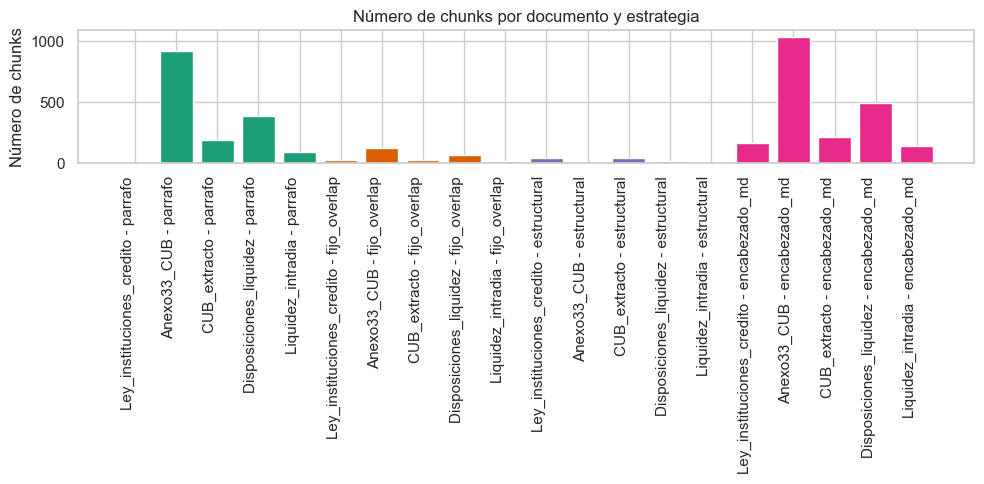

In [24]:
plt.figure(figsize=(10, 5))
for estrategia in df_chunking["estrategia"].unique():
    temp = df_chunking[df_chunking["estrategia"] == estrategia]
    plt.bar(temp["documento"] + " - " + estrategia, temp["n_chunks"])

plt.xticks(rotation=90, ha="right")
plt.title("Número de chunks por documento y estrategia")
plt.ylabel("Número de chunks")
plt.tight_layout()
plt.show()

Una vez evaluadas empíricamente las distintas metodologías de fragmentación, se procedió a seleccionar la técnica que presentara el mejor equilibrio entre la preservación del contexto regulatorio, la granularidad semántica y la consistencia estructural.

Para este pipeline, se definió la **fragmentación de tamaño fijo con solapamiento (fijo_overlap)** como la estrategia base. La justificación principal radica en que esta aproximación genera unidades de texto con una longitud altamente homogénea en todo el corpus.

A diferencia del _chunking_ estrictamente estructural o por párrafo —que frecuentemente produce fragmentos excesivamente extensos ante artículos muy largos— y del particionamiento puro por encabezados —que puede derivar en fragmentos aislados demasiado pequeños—, el enfoque de tamaño fijo y solapado asegura inyecciones de contexto estables hacia el modelo de lenguaje (LLM). Esta estabilidad reduce la varianza computacional, evita truncamientos inesperados y maximiza la precisión en las etapas subsecuentes de vectorización y recuperación semántica.

 ### Dataset unificado para vectorización

 A partir de la técnica de chunking elegida se construye un dataset unificado orientado específicamente a tareas de vectorización y recuperación semántica.

El objetivo de esta etapa es integrar en una sola representación las diferentes fuentes de conocimiento utilizadas por el proyecto:

- _Documentos regulatorios fragmentados en chunks_
- _Estructuras de formularios_
- _Campos individuales_
- _Catálogos regulatorios_

Cada registro consolidado se transforma en una unidad textual autocontenida acompañada de metadatos descriptivos como tipo de documento, sección regulatoria, catálogo asociado y longitud textual. Esta normalización permite que todas las entidades del ecosistema regulatorio puedan coexistir dentro de una misma base vectorial.

Desde la perspectiva de NLP, esta etapa constituye una forma de ingeniería de características semánticas, ya que transforma estructuras heterogéneas (texto libre, tablas regulatorias y formularios) en representaciones comparables dentro de un espacio vectorial común.

La construcción del dataset unificado facilita posteriormente:

- _Generación de embeddings_
- _Búsqueda semántica_
- _Recuperación contextual (RAG)_
- _Asociación automática entre regulación y formularios_
- _Detección de similitud conceptual entre estructuras regulatorias_

Además, la incorporación de metadatos estructurales permite conservar trazabilidad documental durante las etapas posteriores de indexación y recuperación.

**Formulario ML**

In [25]:
registros_texto_ml = []


for doc in docs_ml:
    chunker = RegulacionChunker(EstrategiaChunking.FIJO_OVERLAP)
    chunks_ml = chunker.chunk(doc["texto_limpio"])

    for i, chunk in enumerate(chunks_ml):
        registros_texto_ml.append({
            "id": f"{doc['nombre']}_chunk_{i}",
            "tipo_documento": "regulacion",
            "documento": doc["nombre"],
            "seccion": None,
            "catalogo": None,
            "texto": chunk.page_content,
            "n_palabras": len(chunk.page_content.split())
        })

In [26]:
for i, row in df_campos_ml.iterrows():
    registros_texto_ml.append({
        "id": f"formulario_ml_campo_{i}",
        "tipo_documento": "campo_formulario_ml",
        "documento": "formulario_ml",
        "seccion": row["seccion"],
        "catalogo": None,
        "texto": row["texto_representacion"],
        "n_palabras": row["n_palabras"]
    })

for i, row in df_catalogos_ml.iterrows():
    registros_texto_ml.append({
        "id": f"catalogos_ml_{row['catalogo']}",
        "tipo_documento": "catalogo",
        "documento": "catalogos_ml",
        "seccion": None,
        "catalogo": row["catalogo"],
        "texto": row["texto_representacion"],
        "n_palabras": row["n_palabras"]
    })

df_textos_ml = pd.DataFrame(registros_texto_ml)
display(df_textos_ml.head())
display(df_textos_ml["tipo_documento"].value_counts())

,id,tipo_documento,documento,seccion,catalogo,texto,n_palabras
0,Ley_instituciones_credito_chunk_0,regulacion,Ley_instituciones_credito,NaN,NaN,Las acciones para pedir cuentas para exigir la responsabilidad de las instituciones de crédito y para pedir la remoc...,300
1,Ley_instituciones_credito_chunk_1,regulacion,Ley_instituciones_credito,NaN,NaN,así como con la autorización que otorgará discrecionalmente el Gobierno Federal a través de dicha Secretaría 18 07 2...,300
2,Ley_instituciones_credito_chunk_2,regulacion,Ley_instituciones_credito,NaN,NaN,regional de la localidad de que se trate un aviso dirigido al público que contenga la información relativa a la reub...,300
3,Ley_instituciones_credito_chunk_3,regulacion,Ley_instituciones_credito,NaN,NaN,o administradoras de bienes destinados a sus oficinas Cuando las inversiones de las instituciones de banca de desarr...,300
4,Ley_instituciones_credito_chunk_4,regulacion,Ley_instituciones_credito,NaN,NaN,de que se trate realice sus actividades sujetándose a la legislación extranjera que le sea aplicable y a las disposi...,300


tipo_documento
regulacion             352
campo_formulario_ml     35
catalogo                 6
Name: count, dtype: int64

**Formulario FE**

In [27]:
registros_texto_fe = []


for doc in docs_fe:
    chunker = RegulacionChunker(EstrategiaChunking.FIJO_OVERLAP)
    chunks_fe = chunker.chunk(doc["texto_limpio"])

    for i, chunk in enumerate(chunks_fe):
        registros_texto_fe.append({
            "id": f"{doc['nombre']}_chunk_{i}",
            "tipo_documento": "regulacion",
            "documento": doc["nombre"],
            "seccion": None,
            "catalogo": None,
            "texto": chunk.page_content,
            "n_palabras": len(chunk.page_content.split())
        })


In [28]:
for i, row in df_campos_fe.iterrows():
    registros_texto_fe.append({
        "id": f"formulario_fe_campo_{i}",
        "tipo_documento": "campo_formulario_fe",
        "documento": "formulario_fe",
        "seccion": row["seccion"],
        "catalogo": None,
        "texto": row["texto_representacion"],
        "n_palabras": row["n_palabras"]
    })

for i, row in df_catalogos_fe.iterrows():
    registros_texto_fe.append({
        "id": f"catalogos_fe_{row['catalogo']}",
        "tipo_documento": "catalogo",
        "documento": "catalogos_fe",
        "seccion": None,
        "catalogo": row["catalogo"],
        "texto": row["texto_representacion"],
        "n_palabras": row["n_palabras"]
    })

df_textos_fe = pd.DataFrame(registros_texto_fe)
display(df_textos_fe.head())
display(df_textos_fe["tipo_documento"].value_counts())

,id,tipo_documento,documento,seccion,catalogo,texto,n_palabras
0,Ley_instituciones_credito_chunk_0,regulacion,Ley_instituciones_credito,NaN,NaN,Las acciones para pedir cuentas para exigir la responsabilidad de las instituciones de crédito y para pedir la remoc...,300
1,Ley_instituciones_credito_chunk_1,regulacion,Ley_instituciones_credito,NaN,NaN,así como con la autorización que otorgará discrecionalmente el Gobierno Federal a través de dicha Secretaría 18 07 2...,300
2,Ley_instituciones_credito_chunk_2,regulacion,Ley_instituciones_credito,NaN,NaN,regional de la localidad de que se trate un aviso dirigido al público que contenga la información relativa a la reub...,300
3,Ley_instituciones_credito_chunk_3,regulacion,Ley_instituciones_credito,NaN,NaN,o administradoras de bienes destinados a sus oficinas Cuando las inversiones de las instituciones de banca de desarr...,300
4,Ley_instituciones_credito_chunk_4,regulacion,Ley_instituciones_credito,NaN,NaN,de que se trate realice sus actividades sujetándose a la legislación extranjera que le sea aplicable y a las disposi...,300


tipo_documento
regulacion             352
campo_formulario_fe     28
catalogo                 6
Name: count, dtype: int64

**Formulario LID**

In [29]:
registros_texto_lid = []


for doc in docs_lid:
    chunker = RegulacionChunker(EstrategiaChunking.FIJO_OVERLAP)
    chunks_lid = chunker.chunk(doc["texto_limpio"])

    for i, chunk in enumerate(chunks_lid):
        registros_texto_lid.append({
            "id": f"{doc['nombre']}_chunk_{i}",
            "tipo_documento": "regulacion",
            "documento": doc["nombre"],
            "seccion": None,
            "catalogo": None,
            "texto": chunk.page_content,
            "n_palabras": len(chunk.page_content.split())
        })

In [30]:
for i, row in df_campos_lid.iterrows():
    registros_texto_lid.append({
        "id": f"formulario_lid_campo_{i}",
        "tipo_documento": "campo_formulario_lid",
        "documento": "formulario_lid",
        "seccion": row["seccion"],
        "catalogo": None,
        "texto": row["texto_representacion"],
        "n_palabras": row["n_palabras"]
    })

for i, row in df_catalogos_lid.iterrows():
    registros_texto_lid.append({
        "id": f"catalogos_lid_{row['catalogo']}",
        "tipo_documento": "catalogo",
        "documento": "catalogos_lid",
        "seccion": None,
        "catalogo": row["catalogo"],
        "texto": row["texto_representacion"],
        "n_palabras": row["n_palabras"]
    })

df_textos_lid = pd.DataFrame(registros_texto_lid)
display(df_textos_lid.head())
display(df_textos_lid["tipo_documento"].value_counts())

,id,tipo_documento,documento,seccion,catalogo,texto,n_palabras
0,Ley_instituciones_credito_chunk_0,regulacion,Ley_instituciones_credito,NaN,NaN,Las acciones para pedir cuentas para exigir la responsabilidad de las instituciones de crédito y para pedir la remoc...,300
1,Ley_instituciones_credito_chunk_1,regulacion,Ley_instituciones_credito,NaN,NaN,así como con la autorización que otorgará discrecionalmente el Gobierno Federal a través de dicha Secretaría 18 07 2...,300
2,Ley_instituciones_credito_chunk_2,regulacion,Ley_instituciones_credito,NaN,NaN,regional de la localidad de que se trate un aviso dirigido al público que contenga la información relativa a la reub...,300
3,Ley_instituciones_credito_chunk_3,regulacion,Ley_instituciones_credito,NaN,NaN,o administradoras de bienes destinados a sus oficinas Cuando las inversiones de las instituciones de banca de desarr...,300
4,Ley_instituciones_credito_chunk_4,regulacion,Ley_instituciones_credito,NaN,NaN,de que se trate realice sus actividades sujetándose a la legislación extranjera que le sea aplicable y a las disposi...,300


tipo_documento
regulacion              273
campo_formulario_lid     50
catalogo                 13
Name: count, dtype: int64

### Vectorización: Bag of Words, TF-IDF y Embeddings Semánticos

Como parte de la fase de ingeniería de características, se implementan distintas técnicas de vectorización textual con el objetivo de transformar el corpus regulatorio en representaciones numéricas utilizables por algoritmos de aprendizaje automático y sistemas de recuperación semántica.

En esta etapa se comparan tres enfoques ampliamente utilizados en NLP:

- **Bag of Words (BoW)**: Representa cada documento mediante frecuencias absolutas de términos, sirviendo como línea base tradicional.
- **TF-IDF y su evolución BM25 (Best Matching 25)**: Mientras que TF-IDF pondera los términos según su relevancia relativa, BM25 penaliza de manera inteligente la longitud del documento y la saturación de frecuencias, consolidándose como el estado del arte actual para la recuperación exacta por palabras clave (búsqueda léxica).
- y **Embeddings semánticos**: Representan fragmentos completos de texto mediante vectores densos capaces de capturar sinónimos, relaciones semánticas y el contexto conceptual profundo entre documentos regulatorios.

Estas representaciones permiten cuantificar el contenido de cada fragmento textual, formulario o catálogo. Desde la perspectiva de ingeniería de características, cada enfoque constituye una representación matemática complementaria del conocimiento regulatorio.

Para maximizar la calidad del espacio vectorial, se aplican diversas decisiones de preprocesamiento, incluyendo:

- _Conversión a minúsculas y eliminación de ruido instituciona_
- _Eliminación implícita de términos extremadamente raros o excesivamente frecuentes_
- _Incorporación de stopwords en español_
- _Generación de n-gramas para capturar relaciones terminológicas compuestas frecuentes en regulación financiera_
- _Segmentación estructural mediante estrategias de chunking adaptadas a documentos regulatorios_

Para la representación densa, se utiliza el modelo `text-embedding-3-small` de OpenAI debido a su óptimo balance entre costo computacional, velocidad y capacidad semántica. Estos vectores son indexados en una base de datos vectorial local (ChromaDB). Simultáneamente, se construyen matrices dispersas (TF-IDF / BM25) para habilitar posteriormente arquitecturas de recuperación híbrida.

El objetivo principal de esta fase es establecer las bases matemáticas que permitirán evaluar, en la siguiente etapa, qué mecanismo de recuperación facilita con mayor precisión la inyección de contexto en arquitecturas tipo RAG _(Retrieval-Augmented Generation)_.

In [31]:
from src.nlp_core.retrieval import MotorBusqueda

In [32]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords_es = stopwords.words("spanish")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Alexandro\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [52]:
bow_vectorizer = CountVectorizer(
    lowercase=True,
    min_df=2,
    max_df=0.95,
    stop_words = stopwords_es,
    ngram_range=(1, 1)
)

In [53]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    min_df=2,
    max_df=0.95,
    stop_words = stopwords_es,
    ngram_range=(1, 2),
    norm='l2' # Normalizacion L2 explicita para Similitud Coseno
)

**Formulario ML**

In [54]:
corpus_ml = df_textos_ml["texto"].fillna("").astype(str).tolist()

X_bow_ml = bow_vectorizer.fit_transform(corpus_ml)

X_tfidf_ml = tfidf_vectorizer.fit_transform(corpus_ml)

print("Dimensiones BoW Formulario ML:", X_bow_ml.shape)
print("Dimensiones TF-IDF Formulario ML:", X_tfidf_ml.shape)

Dimensiones BoW Formulario ML: (393, 3077)
Dimensiones TF-IDF Formulario ML: (393, 12829)


**Formulario FE**

In [55]:
corpus_fe = df_textos_fe["texto"].fillna("").astype(str).tolist()

X_bow_fe = bow_vectorizer.fit_transform(corpus_fe)

X_tfidf_fe = tfidf_vectorizer.fit_transform(corpus_fe)


print("Dimensiones BoW Formulario FE:", X_bow_fe.shape)
print("Dimensiones TF-IDF Formulario FE:", X_tfidf_fe.shape)

Dimensiones BoW Formulario FE: (386, 3074)
Dimensiones TF-IDF Formulario FE: (386, 12830)


**Formulario LID**

In [56]:
corpus_lid = df_textos_lid["texto"].fillna("").astype(str).tolist()

X_bow_lid = bow_vectorizer.fit_transform(corpus_lid)

X_tfidf_lid = tfidf_vectorizer.fit_transform(corpus_lid)

print("Dimensiones BoW Formulario LID:", X_bow_lid.shape)
print("Dimensiones TF-IDF Formulario LID:", X_tfidf_lid.shape)


Dimensiones BoW Formulario LID: (336, 2796)
Dimensiones TF-IDF Formulario LID: (336, 10411)


### Selección de características con TF-IDF

En el contexto de este proyecto, la técnica TF-IDF funciona no sólo como un método clásico de recuperación, sino también como una estrategia analítica de **selección de características (feature selection)**, permitiendo identificar matemáticamente qué conceptos regulatorios poseen mayor peso informativo dentro del corpus documental.

Desde la perspectiva del Procesamiento de Lenguaje Natural aplicado a la regulación financiera, esta etapa resulta crítica para discriminar términos genéricos del lenguaje administrativo (por ejemplo, “institución”, “artículo”, “fecha”) frente a conceptos técnicos altamente específicos asociados a reglas de negocio, métricas o fórmulas operativas (ej. “ponderador”, “severidad”, “coeficiente”).

Adicionalmente, debido a la naturaleza matemática de las matrices TF-IDF, esta representación ofrece una **trazabilidad y explicabilidad total**. Por lo tanto, sirve como una línea base (_baseline_) blanca e interpretable para contrastar posteriormente el desempeño de métodos más opacos (black-box), como la búsqueda semántica mediante embeddings densos y arquitecturas RAG avanzadas basadas en modelos de lenguaje.

**Formulario ML**

In [81]:
X_tfidf_ml = tfidf_vectorizer.fit_transform(corpus_ml)
df_top_tfidf_ml = MotorBusqueda.top_tfidf_terms(tfidf_vectorizer, X_tfidf_ml, top_n=20)
display(df_top_tfidf_ml)

,termino,score_promedio_tfidf
0,crédito,0.036403
1,financieros,0.035735
2,efectivo,0.031214
3,operaciones,0.027923
4,activos,0.027072
5,instrumentos,0.022322
6,instrumentos financieros,0.021838
7,monto,0.021475
8,entidad,0.019004
9,entidades,0.018763


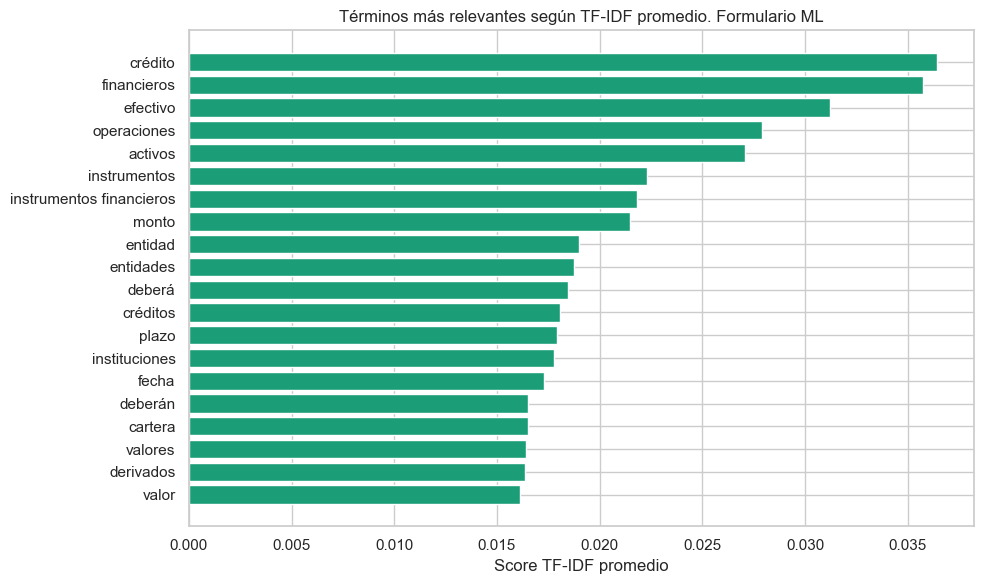

In [42]:
plt.figure(figsize=(10, 6))
plt.barh(df_top_tfidf_ml["termino"][::-1], df_top_tfidf_ml["score_promedio_tfidf"][::-1])
plt.title("Términos más relevantes según TF-IDF promedio. Formulario ML")
plt.xlabel("Score TF-IDF promedio")
plt.tight_layout()
plt.show()

**Formulario FE**

In [43]:
X_tfidf_fe = tfidf_vectorizer.fit_transform(corpus_fe)
df_top_tfidf_fe = MotorBusqueda.top_tfidf_terms(tfidf_vectorizer, X_tfidf_fe, top_n=20)
display(df_top_tfidf_fe)

,termino,score_promedio_tfidf
0,crédito,0.036830
1,financieros,0.036057
2,efectivo,0.031647
3,operaciones,0.028165
4,activos,0.027522
5,instrumentos,0.022524
6,instrumentos financieros,0.022015
7,monto,0.021173
8,entidades,0.018960
9,deberá,0.018678


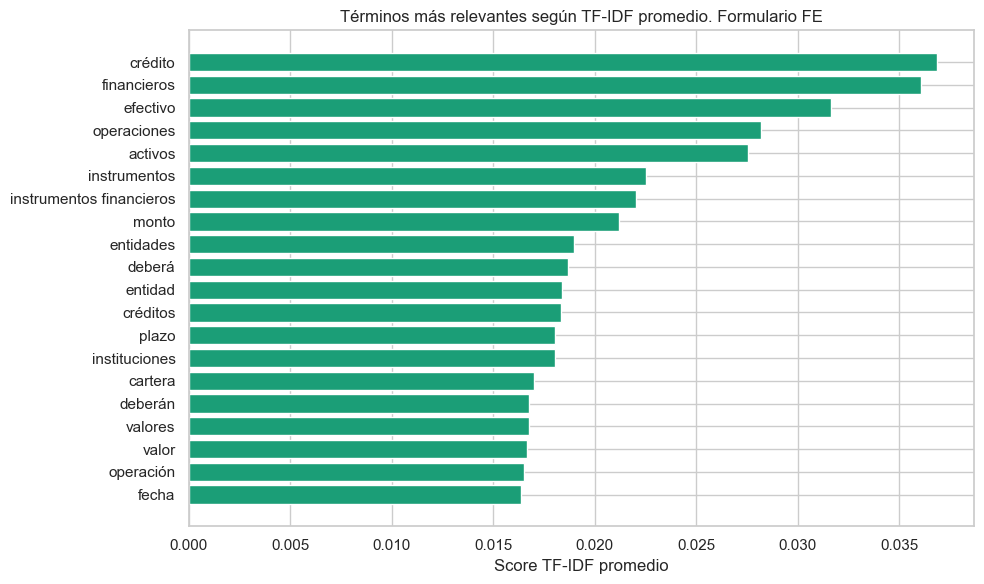

In [44]:
plt.figure(figsize=(10, 6))
plt.barh(df_top_tfidf_fe["termino"][::-1], df_top_tfidf_fe["score_promedio_tfidf"][::-1])
plt.title("Términos más relevantes según TF-IDF promedio. Formulario FE")
plt.xlabel("Score TF-IDF promedio")
plt.tight_layout()
plt.show()

**Formulario LID**

In [45]:
X_tfidf_lid = tfidf_vectorizer.fit_transform(corpus_lid)
df_top_tfidf_lid = MotorBusqueda.top_tfidf_terms(tfidf_vectorizer, X_tfidf_lid, top_n=20)
display(df_top_tfidf_lid)

,termino,score_promedio_tfidf
0,crédito,0.038547
1,financieros,0.037838
2,efectivo,0.034984
3,fecha,0.028875
4,activos,0.025829
5,operaciones,0.025541
6,instrumentos,0.021499
7,instrumentos financieros,0.020903
8,entidad,0.019990
9,créditos,0.019660


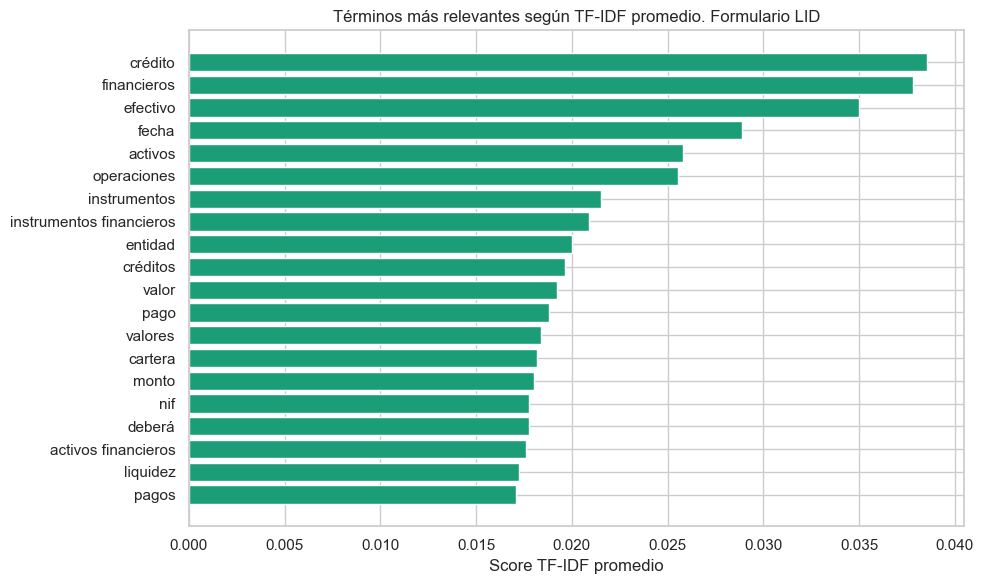

In [46]:
plt.figure(figsize=(10, 6))
plt.barh(df_top_tfidf_lid["termino"][::-1], df_top_tfidf_lid["score_promedio_tfidf"][::-1])
plt.title("Términos más relevantes según TF-IDF promedio. Formulario LID")
plt.xlabel("Score TF-IDF promedio")
plt.tight_layout()
plt.show()

Los resultados de la vectorización TF-IDF demuestran que los tres formularios comparten una intersección léxica fuertemente anclada en el dominio financiero-regulatorio. En ML, FE y LID, los vectores otorgan la mayor relevancia a términos como _crédito, financieros, efectivo, operaciones, activos, instrumentos, monto y entidad_. Esto valida empíricamente que los documentos pertenecen a un mismo ecosistema conceptual y que la técnica logra aislar la "columna vertebral" del lenguaje operativo bancario.

Sin embargo, el modelo también demuestra sensibilidad para discriminar las particularidades de cada requerimiento. En el formulario **FE**, destacan términos como _plazo, cartera y fecha_, lo que sugiere un enfoque orientado a los vencimientos y la clasificación temporal de la información. Por su parte, en el formulario **LID** resaltan palabras como _pago, pagos y liquidez_, dimensiones totalmente coherentes con el propósito regulatorio de perfilar flujos de liquidez intradía.

En conclusión, si bien TF-IDF funciona como una excelente primera aproximación interpretable para perfilar y comparar formularios, su alcance topa con el "límite léxico": extrae la relevancia estadística de las palabras, pero no es capaz de inferir sinónimos ni capturar las relaciones semánticas profundas entre los textos (por ejemplo, no entiende matemáticamente que "recursos disponibles" y "liquidez" pueden referirse a lo mismo). Esta limitación intrínseca justifica la transición metodológica hacia el uso de Embeddings Semánticos.

### Reducción dimensional con TruncatedSVD

Los modelos de vectorización textual, particularmente TF-IDF, generan espacios de representación de muy alta dimensionalidad donde cada término o n-grama constituye una característica independiente. Aunque estas representaciones conservan gran cantidad de información semántica, también incrementan la complejidad computacional y dificultan la interpretación de relaciones globales dentro del corpus.

Con el objetivo de reducir dimensionalidad y explorar la estructura latente de los documentos regulatorios, se aplica la técnica ***Truncated Singular Value Decomposition (TruncatedSVD)***, ampliamente utilizada en NLP para aproximar matrices dispersas de gran tamaño.

Esta técnica permite proyectar los documentos en un espacio semántico reducido donde patrones similares tienden a agruparse automáticamente. En términos prácticos, cada componente generado representa una combinación latente de términos frecuentes que captura parte de la variabilidad estructural del corpus.

La reducción dimensional resulta útil para:

- _Visualizar agrupamientos semánticos_
- _Detectar similitud entre documentos regulatorios_
- _Identificar posibles relaciones entre formularios y catálogos_
- _Reducir ruido en representaciones vectoriales_
- _Facilitar tareas posteriores de clustering o recuperación semántica_

En el contexto del proyecto, este análisis permite explorar si distintas entidades documentales (chunks regulatorios, formularios y catálogos) comienzan a organizarse naturalmente en regiones semánticas diferenciadas dentro del espacio vectorial generado a partir de TF-IDF.

**Formulario ML**

In [47]:
svd_ml = TruncatedSVD(n_components=2, random_state=42)
X_svd_ml = svd_ml.fit_transform(X_tfidf_ml)

df_textos_ml["svd_1"] = X_svd_ml[:, 0]
df_textos_ml["svd_2"] = X_svd_ml[:, 1]

print("Varianza explicada:", svd_ml.explained_variance_ratio_.sum())

Varianza explicada: 0.028519563373439232


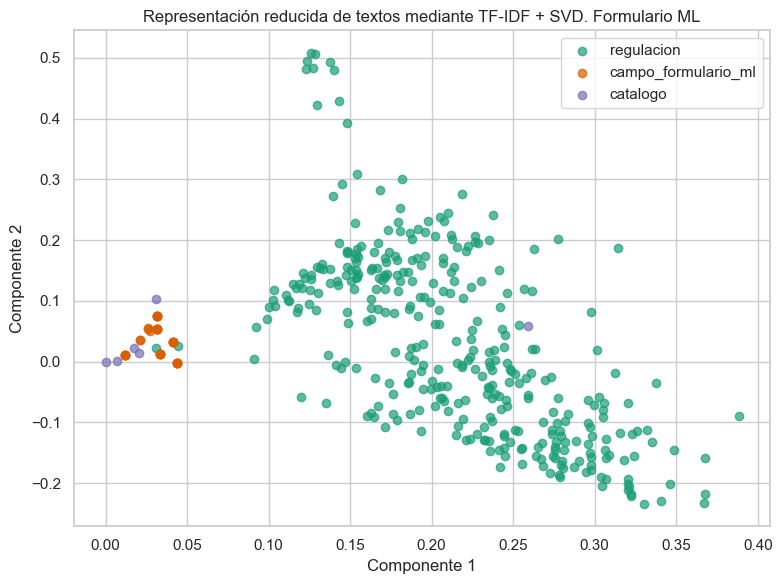

In [48]:
plt.figure(figsize=(8, 6))

for tipo in df_textos_ml["tipo_documento"].unique():
    temp_ml = df_textos_ml[df_textos_ml["tipo_documento"] == tipo]
    plt.scatter(temp_ml["svd_1"], temp_ml["svd_2"], label=tipo, alpha=0.7)

plt.title("Representación reducida de textos mediante TF-IDF + SVD. Formulario ML")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.tight_layout()
plt.show()

**Formulario FE**

In [49]:
svd_fe = TruncatedSVD(n_components=2, random_state=42)
X_svd_fe = svd_fe.fit_transform(X_tfidf_fe)

df_textos_fe["svd_1"] = X_svd_fe[:, 0]
df_textos_fe["svd_2"] = X_svd_fe[:, 1]

print("Varianza explicada:", svd_fe.explained_variance_ratio_.sum())

Varianza explicada: 0.028726043792768684


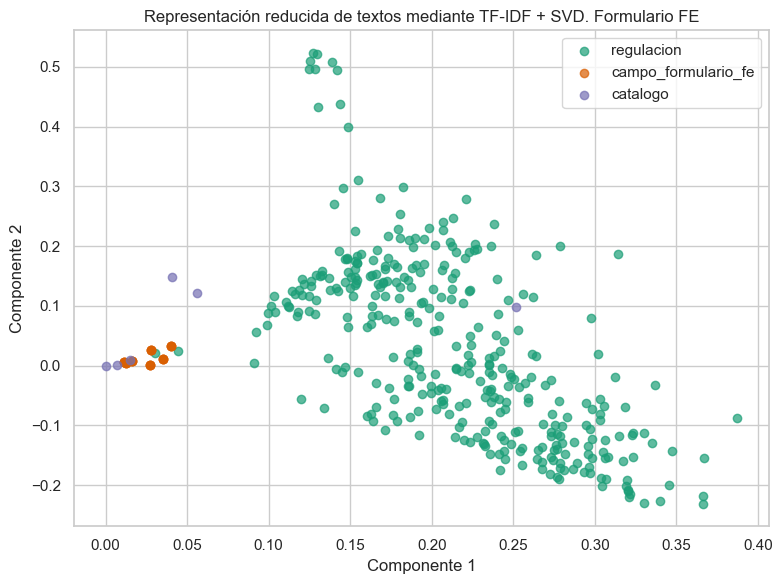

In [50]:
plt.figure(figsize=(8, 6))

for tipo in df_textos_fe["tipo_documento"].unique():
    temp_fe = df_textos_fe[df_textos_fe["tipo_documento"] == tipo]
    plt.scatter(temp_fe["svd_1"], temp_fe["svd_2"], label=tipo, alpha=0.7)

plt.title("Representación reducida de textos mediante TF-IDF + SVD. Formulario FE")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.tight_layout()
plt.show()

**Formulario LID**

In [51]:
svd_lid = TruncatedSVD(n_components=2, random_state=42)
X_svd_lid = svd_lid.fit_transform(X_tfidf_lid)

df_textos_lid["svd_1"] = X_svd_lid[:, 0]
df_textos_lid["svd_2"] = X_svd_lid[:, 1]

print("Varianza explicada:", svd_lid.explained_variance_ratio_.sum())

Varianza explicada: 0.033590766767795474


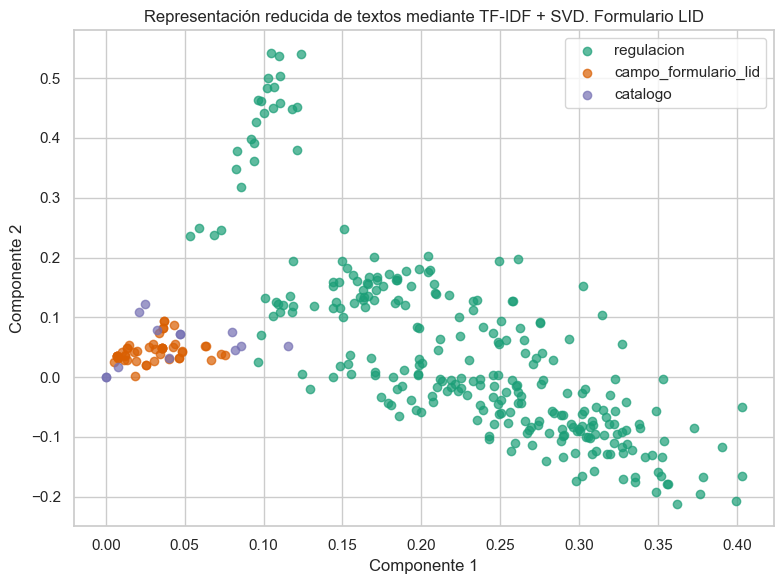

In [52]:
plt.figure(figsize=(8, 6))

for tipo in df_textos_lid["tipo_documento"].unique():
    temp_lid = df_textos_lid[df_textos_lid["tipo_documento"] == tipo]
    plt.scatter(temp_lid["svd_1"], temp_lid["svd_2"], label=tipo, alpha=0.7)

plt.title("Representación reducida de textos mediante TF-IDF + SVD. Formulario LID")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend()
plt.tight_layout()
plt.show()

La reducción dimensional con TruncatedSVD muestra que los tres formularios presentan una estructura muy parecida: los textos de regulación se distribuyen ampliamente en el espacio reducido, mientras que los campos de formulario y catálogos aparecen mucho más concentrados cerca del origen. Esto sugiere que los documentos regulatorios tienen mayor diversidad temática y léxica, mientras que los formularios y catálogos son más breves, estructurados y homogéneos. La varianza explicada por los dos componentes es baja en los tres casos, alrededor de 2.8% en **ML** y **FE**, y 3.3% en **LID**, lo cual es esperable en matrices TF-IDF de alta dimensionalidad, donde la información se reparte entre muchos términos.

En comparación, el formulario **LID** muestra una separación ligeramente más clara entre algunos grupos de regulación y los elementos de formulario/catálogo, además de una varianza explicada un poco mayor. Esto puede indicar que sus textos contienen patrones léxicos algo más diferenciados, probablemente asociados con pagos, liquidez y operaciones intradía. En conjunto, el análisis permite visualizar relaciones generales entre los documentos, pero no debe interpretarse como una separación definitiva de temas, sino como una exploración inicial de la estructura latente del corpus antes de aplicar métodos semánticos más robustos como embeddings o búsqueda vectorial.

### Búsqueda de similitud con TF-IDF

Una vez generadas las representaciones vectoriales del corpus, es posible realizar búsquedas de similitud para recuperar fragmentos regulatorios, estructuras de formularios y catálogos relacionados con una necesidad funcional específica.

A diferencia de las búsquedas tradicionales basadas en sentencias SQL o coincidencias booleanas estrictas, este enfoque utiliza la representación TF-IDF y el cálculo de la **similitud del coseno** para identificar documentos que compartan un alto solapamiento terminológico dentro del espacio vectorial.

En el contexto del proyecto, estas consultas simulan escenarios reales de diseño regulatorio, donde un analista necesita identificar campos potenciales para un nuevo formulario, reglas regulatorias asociadas, catálogos relacionados o estructuras previamente utilizadas en otros requerimientos normativos similares.

El objetivo principal de esta etapa es evaluar si las representaciones léxicas construidas durante la ingeniería de características logran preservar suficiente información direccional para apoyar tareas posteriores de recuperación de información (Information Retrieval) y servir como línea base antes de introducir modelos puramente semánticos.

#### Ejemplos de consultas semánticas

Las siguientes consultas simulan necesidades funcionales reales durante el diseño de formularios regulatorios. En lugar de buscar palabras exactas, las búsquedas intentan recuperar fragmentos normativos y estructuras existentes relacionadas con conceptos regulatorios, variables potenciales y requerimientos de información.


**Formulario ML**

- "Generar campos para identificar la tenencia de nivel 1 de activos líquidos"
- "Identificar información necesaria para obtener los ponderadores de los flujos de entrada de efectivo de la cartera de crédito por tipo de contraparte"

In [53]:
consulta = "Generar campos para identificar la tenencia de nivel 1 de activos líquidos"

X_tfidf_ml = tfidf_vectorizer.fit_transform(corpus_ml)
resultados_tfidf_ml_1 = MotorBusqueda.buscar_tfidf(
    consulta,
    tfidf_vectorizer,
    X_tfidf_ml,
    df_textos_ml,
    k=5
)

display(resultados_tfidf_ml_1)

,id,tipo_documento,documento,seccion,catalogo,score_similitud,texto
249,Disposiciones_liquidez_chunk_2,regulacion,Disposiciones_liquidez,NaN,NaN,0.208294,de descuento C D Grupo de Nivel I A1 B1 0 C1 D1 Grupo de Nivel IIA A2 B2 15 C2 D2 Grupo de Nivel IIB correspondiente...
328,Disposiciones_liquidez_chunk_81,regulacion,Disposiciones_liquidez,NaN,NaN,0.167072,B Los títulos acciones y créditos recibidos en operaciones de reporto o préstamo que a su vez se hayan restringido u...
248,Disposiciones_liquidez_chunk_1,regulacion,Disposiciones_liquidez,NaN,NaN,0.155624,de internet dentro del mes inmediato siguiente a la fecha en que las Instituciones deban realizar la difusión a que ...
329,Disposiciones_liquidez_chunk_82,regulacion,Disposiciones_liquidez,NaN,NaN,0.149833,como Activos Líquidos Elegibles que pertenecen al grupo de nivel IIA de conformidad con las presentes disposiciones ...
74,Anexo33_CUB_chunk_37,regulacion,Anexo33_CUB,NaN,NaN,0.129473,especiales Pág 19 Revelaciones relativas a la determinación del valor razonable Las entidades respecto del Precio Ac...


In [54]:
consulta = "Identificar información necesaria para obtener los ponderadores de los flujos de entrada de efectivo de la cartera de crédito por tipo de contraparte"

X_tfidf_ml = tfidf_vectorizer.fit_transform(corpus_ml)
resultados_tfidf_ml_2 = MotorBusqueda.buscar_tfidf(
    consulta,
    tfidf_vectorizer,
    X_tfidf_ml,
    df_textos_ml,
    k=5
)

display(resultados_tfidf_ml_2)

,id,tipo_documento,documento,seccion,catalogo,score_similitud,texto
304,Disposiciones_liquidez_chunk_57,regulacion,Disposiciones_liquidez,NaN,NaN,0.202492,contraparte i considerando los activos otorgados en garantía a dicha contraparte SND Flujo de salida por instrumento...
302,Disposiciones_liquidez_chunk_55,regulacion,Disposiciones_liquidez,NaN,NaN,0.186199,operaciones no señaladas anteriormente como un flujo contractual de entrada 100 Para propósitos de este anexo se ent...
303,Disposiciones_liquidez_chunk_56,regulacion,Disposiciones_liquidez,NaN,NaN,0.173864,derivados en las cuales se mantiene una posición ganadora de aquellas en las cuales mantiene una posición perdedora ...
228,Anexo33_CUB_chunk_191,regulacion,Anexo33_CUB,NaN,NaN,0.138662,El estado de flujos de efectivo tiene como objetivo principal proporcionar a los usuarios de los estados financieros...
121,Anexo33_CUB_chunk_84,regulacion,Anexo33_CUB,NaN,NaN,0.128338,no está asegurada o que solo está garantizada por una parte relacionada del mismo Normas de reconocimiento y valuaci...


**Formulario FE**

- "Identificar conceptos regulatorios relacionados con financiamiento estable requerido y disponible"
- "Generar variables para clasificar pasivos según estabilidad y plazo contractual"

Estas consultas permiten evaluar la capacidad de las estrategias de fragmentación y vectorización para preservar contexto regulatorio y recuperar información útil para futuras tareas de generación automatizada de formularios.



In [55]:
consulta = "Identificar conceptos regulatorios relacionados con financiamiento estable requerido y disponible"
X_tfidf_fe = tfidf_vectorizer.fit_transform(corpus_fe)
resultados_tfidf_fe_1 = MotorBusqueda.buscar_tfidf(
    consulta,
    tfidf_vectorizer,
    X_tfidf_fe,
    df_textos_fe,
    k=5
)

display(resultados_tfidf_fe_1)

,id,tipo_documento,documento,seccion,catalogo,score_similitud,texto
339,Disposiciones_liquidez_chunk_92,regulacion,Disposiciones_liquidez,NaN,NaN,0.289533,el monto que corresponda a las operaciones con instrumentos derivados cuando el costo actual de reemplazo en los tér...
270,Disposiciones_liquidez_chunk_23,regulacion,Disposiciones_liquidez,NaN,NaN,0.265072,de III En el escenario V además de las medidas aplicables a las Instituciones que se ubiquen en el escenario IV la s...
327,Disposiciones_liquidez_chunk_80,regulacion,Disposiciones_liquidez,NaN,NaN,0.225660,posiciones pasivas de las operaciones con instrumentos financieros derivados es decir cuando su costo de remplazo se...
320,Disposiciones_liquidez_chunk_73,regulacion,Disposiciones_liquidez,NaN,NaN,0.216467,Para el presente anexo solo deberán tomarse en cuenta los activos que no estén otorgados en garantía ni sujetos a re...
276,Disposiciones_liquidez_chunk_29,regulacion,Disposiciones_liquidez,NaN,NaN,0.214253,la Comisión ordene modificaciones al plan de restauración de que se trate este deberá presentarse nuevamente para su...


In [56]:
consulta = "Generar variables para clasificar pasivos según estabilidad y plazo contractual"
X_tfidf_fe = tfidf_vectorizer.fit_transform(corpus_fe)
resultados_tfidf_fe_2 = MotorBusqueda.buscar_tfidf(
    consulta,
    tfidf_vectorizer,
    X_tfidf_fe,
    df_textos_fe,
    k=5
)

display(resultados_tfidf_fe_2)

,id,tipo_documento,documento,seccion,catalogo,score_similitud,texto
128,Anexo33_CUB_chunk_91,regulacion,Anexo33_CUB,NaN,NaN,0.086490,los flujos de efectivo futuros estimados que se recibirán por principal e intereses conforme al esquema de pagos pac...
318,Disposiciones_liquidez_chunk_71,regulacion,Disposiciones_liquidez,NaN,NaN,0.072643,un año C Los pasivos con plazo residual igual o mayor a un año II Pasivos con ponderación del 95 A Depósitos a la vi...
125,Anexo33_CUB_chunk_88,regulacion,Anexo33_CUB,NaN,NaN,0.063197,cartera de crédito al momento de la transacción Cualquier otro gasto que no esté asociado al otorgamiento del crédit...
204,Anexo33_CUB_chunk_167,regulacion,Anexo33_CUB,NaN,NaN,0.059163,de exigibilidad inmediata de corto plazo monto de las amortizaciones cuyo plazo por vencer sea menor o igual a un añ...
252,Disposiciones_liquidez_chunk_5,regulacion,Disposiciones_liquidez,NaN,NaN,0.058133,de dichas operaciones III Tratándose de las emisiones de la propia Institución cuyo plazo remanente sea mayor a trei...


**Formulario LID**

- "Generar campos para identificar las fuentes de liquidez disponible al inicio del día"
- "Identificar requerimientos relacionados con obligaciones de pago intradía"


In [57]:
consulta = "Generar campos para identificar las fuentes de liquidez disponible al inicio del día"

X_tfidf_lid = tfidf_vectorizer.fit_transform(corpus_lid)
resultados_tfidf_lid_1 = MotorBusqueda.buscar_tfidf(
    consulta,
    tfidf_vectorizer,
    X_tfidf_lid,
    df_textos_lid,
    k=5
)

display(resultados_tfidf_lid_1)

,id,tipo_documento,documento,seccion,catalogo,score_similitud,texto
271,Liquidez_intradia_chunk_24,regulacion,Liquidez_intradia,NaN,NaN,0.329947,especialmente cuando su monto de liquidez intradía disponible al inicio del día hábil suele ser bajo En tales circun...
277,formulario_lid_campo_4,campo_formulario_lid,formulario_lid,seccion_I_liquiddisp_inicio_dia,NaN,0.292855,saldo | saldo disponible al inicio del dia | numerico |
255,Liquidez_intradia_chunk_8,regulacion,Liquidez_intradia,NaN,NaN,0.289280,intradía disponible al inicio de cada día hábil en el periodo de reporte así como el monto promedio de liquidez intr...
254,Liquidez_intradia_chunk_7,regulacion,Liquidez_intradia,NaN,NaN,0.271474,algún momento intradía necesitará acceso a liquidez intradía para financiar ese saldo El monto mínimo de liquidez in...
260,Liquidez_intradia_chunk_13,regulacion,Liquidez_intradia,NaN,NaN,0.204749,capacidad para obtener liquidez intradía de su s banco s corresponsal es 36 Los bancos que gestionan liquidez intrad...


In [58]:
consulta = "Identificar requerimientos relacionados con obligaciones de pago intradía"

resultados_tfidf_lid_2 = MotorBusqueda.buscar_tfidf(
    consulta,
    tfidf_vectorizer,
    X_tfidf_lid,
    df_textos_lid,
    k=5
)

display(resultados_tfidf_lid_2)

,id,tipo_documento,documento,seccion,catalogo,score_similitud,texto
327,catalogos_lid_identificador_pago,catalogo,catalogos_lid,NaN,identificador_pago,0.529906,Sin obligaciones de pago Con obligaciones de pago
328,catalogos_lid_identificador_liquidacion,catalogo,catalogos_lid,NaN,identificador_liquidacion,0.529906,Sin obligaciones de pago Con obligaciones de pago
247,Liquidez_intradia_chunk_0,regulacion,Liquidez_intradia,NaN,NaN,0.191346,Herramientas de monitoreo para la gestión de la liquidez intradía Abril de 2013 bis org Contenido I Introducción 1 L...
250,Liquidez_intradia_chunk_3,regulacion,Liquidez_intradia,NaN,NaN,0.169354,Sección III Los escenarios de tensión de liquidez intradía Sección IV El alcance de aplicación de las herramientas S...
248,Liquidez_intradia_chunk_1,regulacion,Liquidez_intradia,NaN,NaN,0.168783,intradía suficiente para cumplir sus objetivos intradía iv Tener la capacidad de gestionar y movilizar colateral seg...


La búsqueda de similitud léxica con TF-IDF muestra resultados mixtos. En varios casos, el método recupera fragmentos conceptualmente relacionados con las consultas, especialmente cuando existe coincidencia directa de términos relevantes. Por ejemplo, en el formulario LID, las consultas sobre fuentes de "liquidez disponible" y "obligaciones de pago" recuperan resultados sumamente coherentes, incluyendo fragmentos de regulación, campos del formulario y catálogos directamente asociados con esos términos. Esto indica que TF-IDF es altamente efectivo para localizar información cuando la consulta del analista comparte el vocabulario exacto de los documentos.

Sin embargo, en los formularios ML y FE, los resultados evidencian una dependencia absoluta de las coincidencias léxicas en detrimento de una comprensión profunda de la consulta. Aunque se recuperan fragmentos relacionados de forma general con términos como crédito, activos, flujos o pasivos, los resultados **no siempre responden a la intención real de la búsqueda**.

Esto confirma el diagnóstico inicial: TF-IDF funciona como una excelente línea base (_baseline_) interpretable, pero su desempeño decae abruptamente frente a la "brecha de vocabulario" (cuando la consulta usa palabras distintas a las del documento) o cuando se requiere inferir relaciones conceptuales abstractas. Por ello, estos resultados sientan el precedente perfecto para evaluar e introducir la recuperación mediante embeddings semánticos y bases vectoriales (ChromaDB).

## Búsqueda de similitud semántica con Embeddings y ChromaDB

Como contraparte a la representación TF-IDF, se implementa una arquitectura de búsqueda semántica basada en embeddings densos (OpenAI) almacenados en la base de datos vectorial ChromaDB. A diferencia de TF-IDF, que depende estrictamente de las coincidencias léxicas y la ponderación estadística de los términos, los embeddings densos proyectan los fragmentos regulatorios, los campos de formularios y los catálogos en un espacio vectorial continuo.

Este enfoque permite capturar el contexto y el significado subyacente, logrando recuperar información relevante incluso cuando la terminología utilizada en la consulta difiere del texto del documento (superando la brecha de vocabulario).

Para este proyecto, esta característica resulta fundamental: permite que un analista financiero describa una necesidad de negocio utilizando lenguaje natural cotidiano y que el sistema sea capaz de abstraer la intención para recuperar los requerimientos normativos asociados.

En esta sección se utilizan exactamente las mismas consultas empleadas en el escenario de TF-IDF. El objetivo es ejecutar una evaluación comparativa (benchmark) y determinar si la representación semántica logra superar el límite léxico de la etapa anterior, recuperando resultados más alineados con la intención funcional de cada consulta.

A continuación, se realiza la indexación de los datasets unificados de cada formulario utilizando ChromaDB. Cada colección vectorial contendrá los documentos regulatorios (chunks), los campos del formulario y los catálogos, todos representados ahora mediante embeddings semánticos.

Una vez generadas las bases vectoriales, se ejecutarán exactamente las mismas consultas utilizadas en la evaluación de TF-IDF. El objetivo es comprobar estadísticamente si la búsqueda semántica permite recuperar fragmentos con mayor cercanía conceptual a la consulta original, incluso cuando no existe una coincidencia exacta de los términos.

In [59]:
from src.nlp_core.vectorizacion import MotorVectorizacion
motor_vec = MotorVectorizacion()

In [60]:
X_chroma_ml = motor_vec.indexar_dataset_unificado(df_textos_ml, collection_name = "regulacion_formulario_ml")

X_chroma_fe = motor_vec.indexar_dataset_unificado(df_textos_fe, collection_name = "regulacion_formulario_fe")

X_chroma_lid = motor_vec.indexar_dataset_unificado(df_textos_lid, collection_name = "regulacion_formulario_lid")

Indexando dataset masivo en ChromaDB...


2026-05-17 14:18:07,400 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-05-17 14:18:09,348 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


"Base vectorial creada y almacenada en" C:\bluepill5\Hack\Maestria\ProyectoIntegrador\proyecto_disf_npl\data\03_output\chroma_db
Indexando dataset masivo en ChromaDB...


2026-05-17 14:18:11,831 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-05-17 14:18:13,386 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


"Base vectorial creada y almacenada en" C:\bluepill5\Hack\Maestria\ProyectoIntegrador\proyecto_disf_npl\data\03_output\chroma_db
Indexando dataset masivo en ChromaDB...


2026-05-17 14:18:15,637 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"
2026-05-17 14:18:17,772 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


"Base vectorial creada y almacenada en" C:\bluepill5\Hack\Maestria\ProyectoIntegrador\proyecto_disf_npl\data\03_output\chroma_db


Se importa la función personalizada creada para este cometido

In [63]:
from src.nlp_core.vectorizacion import buscar_similitud_chroma

**Formulario ML**

Consultas utilizadas:

- "Generar campos para identificar la tenencia de nivel 1 de activos líquidos"
- "Identificar información necesaria para obtener los ponderadores de las entradas de efectivo de la cartera de crédito por tipo de contraparte"

In [65]:
motor_busqueda_ml = MotorBusqueda(collection_name="regulacion_formulario_ml")

In [66]:
consulta_ml_1 = "Generar campos para identificar la tenencia de nivel 1 de activos líquidos"

resultados_chroma_ml_1_df, _ = motor_busqueda_ml.buscar_similitud_tabular(
    query=consulta_ml_1,
    k=5
)

display(resultados_chroma_ml_1_df)

2026-05-17 14:22:57,017 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,n_palabras,texto
0,1,0.861925,Disposiciones_liquidez_chunk_3,regulacion,Disposiciones_liquidez,None,None,300,dentro de la clasificación de Activos Líquidos Elegibles este podrá seguir computando en su clasificación original d...
1,2,0.866409,Disposiciones_liquidez_chunk_65,regulacion,Disposiciones_liquidez,None,None,300,de las presentes disposiciones según corresponda 3 Las celdas señaladas como No aplica no deberán de ser llenadas 4 ...
2,3,0.870579,Disposiciones_liquidez_chunk_1,regulacion,Disposiciones_liquidez,None,None,300,de internet dentro del mes inmediato siguiente a la fecha en que las Instituciones deban realizar la difusión a que ...
3,4,0.873386,Disposiciones_liquidez_chunk_50,regulacion,Disposiciones_liquidez,None,None,300,operaciones de compra venta de títulos fecha valor cuando resulte una posición pasiva una vez compensada la parte ac...
4,5,0.877078,Disposiciones_liquidez_chunk_2,regulacion,Disposiciones_liquidez,None,None,300,de descuento C D Grupo de Nivel I A1 B1 0 C1 D1 Grupo de Nivel IIA A2 B2 15 C2 D2 Grupo de Nivel IIB correspondiente...


In [67]:
consulta_ml_2 =  "Identificar información necesaria para obtener los ponderadores de los flujos de entrada de efectivo de la cartera de crédito por tipo de contraparte"

resultados_chroma_ml_2_df, _ = motor_busqueda_ml.buscar_similitud_tabular(
    query=consulta_ml_2,
    k=5
)

display(resultados_chroma_ml_2_df)

2026-05-17 14:23:29,513 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,n_palabras,texto
0,1,0.765382,Anexo33_CUB_chunk_89,regulacion,Anexo33_CUB,None,None,300,efectivo Deduciendo de los flujos de efectivo futuros estimados a recibir determinados conforme al numeral anterior ...
1,2,0.794995,Disposiciones_liquidez_chunk_57,regulacion,Disposiciones_liquidez,None,None,300,contraparte i considerando los activos otorgados en garantía a dicha contraparte SND Flujo de salida por instrumento...
2,3,0.805385,Disposiciones_liquidez_chunk_65,regulacion,Disposiciones_liquidez,None,None,300,de las presentes disposiciones según corresponda 3 Las celdas señaladas como No aplica no deberán de ser llenadas 4 ...
3,4,0.810149,Disposiciones_liquidez_chunk_91,regulacion,Disposiciones_liquidez,None,None,300,35 de acuerdo al Método Estándar para riesgo de crédito de Basilea II 22 Cartera de crédito de vivienda en etapas 1 ...
4,5,0.819939,Disposiciones_liquidez_chunk_56,regulacion,Disposiciones_liquidez,None,None,300,derivados en las cuales se mantiene una posición ganadora de aquellas en las cuales mantiene una posición perdedora ...


**Formulario FE**

Consultas utilizadas:

- "Identificar conceptos regulatorios relacionados con financiamiento estable requerido y disponible"
- "Generar variables para clasificar pasivos según estabilidad y plazo contractual"

In [68]:
motor_busqueda_fe = MotorBusqueda(collection_name="regulacion_formulario_fe")

In [69]:
consulta_fe_1 = "Identificar conceptos regulatorios relacionados con financiamiento estable requerido y disponible"

resultados_chroma_fe_1_df, _ = motor_busqueda_fe.buscar_similitud_tabular(
    query=consulta_fe_1,
    k=5
)

display(resultados_chroma_fe_1_df)

2026-05-17 14:24:48,692 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,n_palabras,texto
0,1,0.662168,Disposiciones_liquidez_chunk_69,regulacion,Disposiciones_liquidez,None,None,300,consorcio o grupo empresarial que de acuerdo con las Políticas y Criterios el consejo de administración de la Instit...
1,2,0.697013,Disposiciones_liquidez_chunk_87,regulacion,Disposiciones_liquidez,None,None,300,cálculo de los referidos promedios trimestrales las Instituciones deberán utilizar los importes y coeficientes que h...
2,3,0.717540,Disposiciones_liquidez_chunk_80,regulacion,Disposiciones_liquidez,None,None,300,posiciones pasivas de las operaciones con instrumentos financieros derivados es decir cuando su costo de remplazo se...
3,4,0.740209,Disposiciones_liquidez_chunk_90,regulacion,Disposiciones_liquidez,None,None,300,Operaciones Interdependientes 11 Suma de la referencia 12 y referencia 13 12 El monto que corresponda a las operacio...
4,5,0.740998,Disposiciones_liquidez_chunk_88,regulacion,Disposiciones_liquidez,None,None,300,de Financiamiento Estable Neto No aplica No aplica No aplica No aplica No aplica No aplica No aplica No aplica 16 De...


In [71]:
consulta_fe_2 = "Generar variables para clasificar pasivos según estabilidad y plazo contractual"

resultados_chroma_fe_2_df, _ = motor_busqueda_fe.buscar_similitud_tabular(
    query=consulta_fe_2,
    k=5
)

display(resultados_chroma_fe_2_df)

2026-05-17 14:25:07,611 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,n_palabras,texto
0,1,0.911145,Anexo33_CUB_chunk_172,regulacion,Anexo33_CUB,None,None,300,empresarial o comercial Acredores por liquidación de operaciones Emittentes financieros Acredores por cuentas de mar...
1,2,0.930384,Disposiciones_liquidez_chunk_70,regulacion,Disposiciones_liquidez,None,None,300,Financiamiento Estable Disponible Las Instituciones para determinar el Monto de Financiamiento Estable Disponible de...
2,3,0.932208,Disposiciones_liquidez_chunk_50,regulacion,Disposiciones_liquidez,None,None,300,operaciones de compra venta de títulos fecha valor cuando resulte una posición pasiva una vez compensada la parte ac...
3,4,0.947278,Disposiciones_liquidez_chunk_71,regulacion,Disposiciones_liquidez,None,None,300,un año C Los pasivos con plazo residual igual o mayor a un año II Pasivos con ponderación del 95 A Depósitos a la vi...
4,5,0.971382,Disposiciones_liquidez_chunk_84,regulacion,Disposiciones_liquidez,None,None,300,contemplada en el contrato El contrato marco no deberá permitir que en caso de incumplimiento de una de las partes l...


**Formulario LID**

Consultas utilizadas:

- "Generar campos para identificar las fuentes de liquidez disponible al inicio del día"
- "Identificar requerimientos relacionados con obligaciones de pago intradía"

In [73]:
motor_busqueda_lid = MotorBusqueda(collection_name="regulacion_formulario_lid")

In [74]:
consulta_lid_1 = "Generar campos para identificar las fuentes de liquidez disponible al inicio del día"

resultados_chroma_lid_1_df, _ = motor_busqueda_lid.buscar_similitud_tabular(
    query=consulta_lid_1,
    k=5
)

display(resultados_chroma_lid_1_df)

2026-05-17 14:26:00,063 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,n_palabras,texto
0,1,0.761277,Liquidez_intradia_chunk_8,regulacion,Liquidez_intradia,None,None,300,intradía disponible al inicio de cada día hábil en el periodo de reporte así como el monto promedio de liquidez intr...
1,2,0.792882,Liquidez_intradia_chunk_7,regulacion,Liquidez_intradia,None,None,300,algún momento intradía necesitará acceso a liquidez intradía para financiar ese saldo El monto mínimo de liquidez in...
2,3,0.814862,Liquidez_intradia_chunk_3,regulacion,Liquidez_intradia,None,None,300,Sección III Los escenarios de tensión de liquidez intradía Sección IV El alcance de aplicación de las herramientas S...
3,4,0.832064,Liquidez_intradia_chunk_5,regulacion,Liquidez_intradia,None,None,300,lograrlo se desarrollaron siete herramientas de monitoreo separadas véase el Cuadro 1 Como no todas las herramientas...
4,5,0.834951,Liquidez_intradia_chunk_4,regulacion,Liquidez_intradia,None,None,300,libremente en liquidez intradía Líneas de crédito garantizadas y no garantizadas comprometidas y no comprometidas di...


In [75]:
consulta_lid_2 = "Identificar requerimientos relacionados con obligaciones de pago intradía"

resultados_chroma_lid_2_df, _ = motor_busqueda_lid.buscar_similitud_tabular(
    query=consulta_lid_2,
    k=5
)

display(resultados_chroma_lid_2_df)

2026-05-17 14:26:11,685 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,n_palabras,texto
0,1,0.758841,Liquidez_intradia_chunk_8,regulacion,Liquidez_intradia,None,None,300,intradía disponible al inicio de cada día hábil en el periodo de reporte así como el monto promedio de liquidez intr...
1,2,0.766201,Liquidez_intradia_chunk_9,regulacion,Liquidez_intradia,None,None,300,pagos brutos enviados y recibidos durante el periodo de reporte así como la cifra promedio diaria de pagos brutos re...
2,3,0.786176,Liquidez_intradia_chunk_24,regulacion,Liquidez_intradia,None,None,300,especialmente cuando su monto de liquidez intradía disponible al inicio del día hábil suele ser bajo En tales circun...
3,4,0.805984,Liquidez_intradia_chunk_20,regulacion,Liquidez_intradia,None,None,300,unidades Pagos brutos recibidos 200 400 300 350 150 1 400 unidades A iv Obligaciones con horario específico 200 valo...
4,5,0.831127,Liquidez_intradia_chunk_4,regulacion,Liquidez_intradia,None,None,300,libremente en liquidez intradía Líneas de crédito garantizadas y no garantizadas comprometidas y no comprometidas di...


La evaluación de la búsqueda semántica mediante embeddings densos (ChromaDB) demuestra una capacidad de recuperación significativamente más flexible y robusta que TF-IDF, logrando superar la dependencia de las coincidencias léxicas exactas.

En el caso de los formularios ML y FE, el modelo logra recuperar exitosamente fragmentos normativos relacionados con activos líquidos, flujos de efectivo, financiamiento estable, derivados y posiciones. Esto demuestra que la representación vectorial logra abstraer la "intención" de la consulta y mapearla con conceptos regulatorios cercanos. No obstante, se observa que en ciertas ocasiones el modelo incurre en recuperaciones demasiado amplias o tangenciales, perdiendo precisión a la hora de devolver campos específicos del formulario.

Por el contrario, en el formulario LID los resultados alcanzan su nivel óptimo. Para búsquedas sobre fuentes de liquidez al inicio del día y obligaciones de pago intradía, la base vectorial recupera fragmentos directamente vinculados a líneas de crédito, saldos disponibles y mecanismos de pago. Esto confirma que los embeddings maximizan su eficacia cuando el dominio semántico de la consulta está estrictamente delimitado.

En conclusión, este enfoque supera ampliamente a TF-IDF como motor principal para la recuperación contextual (RAG) en la extracción regulatoria. Sin embargo, la tendencia ocasional a generar "resultados amplios" justifica la necesidad de combinar ambos mundos (léxico y semántico) mediante estrategias de Búsqueda Híbrida.

## Búsqueda Híbrida (Ensemble Retrieval)

Tras evaluar de forma aislada la búsqueda léxica (TF-IDF/BM25) y la búsqueda semántica (Embeddings), se concluye que ambas poseen fortalezas complementarias. Para mitigar la "deriva semántica" de los embeddings y la "rigidez" de la búsqueda léxica, se implementa una **Búsqueda Híbrida**.

Utilizando el algoritmo _Reciprocal Rank Fusion (RRF)_ a través de la librería LangChain (`EnsembleRetriever`), el sistema ejecuta ambas búsquedas en paralelo y fusiona matemáticamente los rankings. Esto garantiza que el contexto inyectado al modelo de lenguaje (LLM) durante la fase RAG sea lo más rico y preciso posible.

In [ ]:
from langchain_core.documents import Document
from src.nlp_core.retrieval import MotorBusqueda

In [41]:
# Preparamos los textos para que BM25 los pueda leer
documentos_para_bm25_ml = [
    Document(
        page_content=row["texto"], 
        metadata={
            "id": row.get("id"),
            "tipo_documento": row.get("tipo_documento"),
            "documento": row.get("documento"),
            "seccion": row.get("seccion"),
            "catalogo": row.get("catalogo")
        }
    )
    for _, row in df_textos_ml.iterrows()
]

documentos_para_bm25_fe = [
    Document(
        page_content=row["texto"], 
        metadata={
            "id": row.get("id"),
            "tipo_documento": row.get("tipo_documento"),
            "documento": row.get("documento"),
            "seccion": row.get("seccion"),
            "catalogo": row.get("catalogo")
        }
    )
    for _, row in df_textos_fe.iterrows()
]

documentos_para_bm25_lid = [
    Document(
        page_content=row["texto"], 
        metadata={
            "id": row.get("id"),
            "tipo_documento": row.get("tipo_documento"),
            "documento": row.get("documento"),
            "seccion": row.get("seccion"),
            "catalogo": row.get("catalogo")
        }
    )
    for _, row in df_textos_lid.iterrows()
]

In [42]:
# Instanciamos el motor apuntando a tu colección
motor_hibrido_ml = MotorBusqueda(collection_name="regulacion_formulario_ml")
motor_hibrido_fe = MotorBusqueda(collection_name="regulacion_formulario_fe")
motor_hibrido_lid = MotorBusqueda(collection_name="regulacion_formulario_lid")

**Formulario ML**

Consultas utilizadas:

- "Generar campos para identificar la tenencia de nivel 1 de activos líquidos"
- "Identificar información necesaria para obtener los ponderadores de las entradas de efectivo de la cartera de crédito por tipo de contraparte"


In [49]:
consulta_ml_1 = "Generar campos para identificar la tenencia de nivel 1 de activos líquidos"

# Ejecutamos la Búsqueda Híbrida
resultados_hibridos_ml_1_df, _ = motor_hibrido_ml.buscar_hibrido(
    query=consulta_ml_1, 
    documentos_bm25=documentos_para_bm25_ml,
    k=5,
    weights=[0.5, 0.5] # 50% Léxico, 50% Semántico
)

display(resultados_hibridos_ml_1_df)

Ejecutando Búsqueda Híbrida para: 'Generar campos para identificar la tenencia de nivel 1 de activos líquidos'...


2026-05-17 17:04:02,565 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,texto
0,1,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_88,regulacion,Disposiciones_liquidez,NaN,NaN,de Financiamiento Estable Neto No aplica No aplica No aplica No aplica No aplica No aplica No aplica No aplica 16 De...
1,2,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_3,regulacion,Disposiciones_liquidez,NaN,NaN,dentro de la clasificación de Activos Líquidos Elegibles este podrá seguir computando en su clasificación original d...
2,3,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_87,regulacion,Disposiciones_liquidez,NaN,NaN,cálculo de los referidos promedios trimestrales las Instituciones deberán utilizar los importes y coeficientes que h...
3,4,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_65,regulacion,Disposiciones_liquidez,NaN,NaN,de las presentes disposiciones según corresponda 3 Las celdas señaladas como No aplica no deberán de ser llenadas 4 ...
4,5,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_74,regulacion,Disposiciones_liquidez,NaN,NaN,ya hubieran sido liquidadas Es decir los activos a recibir por operaciones fecha valor recibirán el tratamiento como...


In [48]:
consulta_ml_2 =  "Identificar información necesaria para obtener los ponderadores de los flujos de entrada de efectivo de la cartera de crédito por tipo de contraparte"

# Ejecutamos la Búsqueda Híbrida
resultados_hibridos_ml_2_df, _ = motor_hibrido_ml.buscar_hibrido(
    query=consulta_ml_2, 
    documentos_bm25=documentos_para_bm25_ml,
    k=5,
    weights=[0.5, 0.5] # 50% Léxico, 50% Semántico
)

display(resultados_hibridos_ml_2_df)

Ejecutando Búsqueda Híbrida para: 'Identificar información necesaria para obtener los ponderadores de los flujos de entrada de efectivo de la cartera de crédito por tipo de contraparte'...


2026-05-17 17:03:46,133 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,texto
0,1,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_57,regulacion,Disposiciones_liquidez,NaN,NaN,contraparte i considerando los activos otorgados en garantía a dicha contraparte SND Flujo de salida por instrumento...
1,2,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_56,regulacion,Disposiciones_liquidez,NaN,NaN,derivados en las cuales se mantiene una posición ganadora de aquellas en las cuales mantiene una posición perdedora ...
2,3,N/A (Híbrido/RRF),Anexo33_CUB_chunk_89,regulacion,Anexo33_CUB,NaN,NaN,efectivo Deduciendo de los flujos de efectivo futuros estimados a recibir determinados conforme al numeral anterior ...
3,4,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_58,regulacion,Disposiciones_liquidez,NaN,NaN,aquellas en las cuales mantiene una posición perdedora Los flujos de entrada se compensarán con los flujos de salida...
4,5,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_65,regulacion,Disposiciones_liquidez,NaN,NaN,de las presentes disposiciones según corresponda 3 Las celdas señaladas como No aplica no deberán de ser llenadas 4 ...


**Formulario FE**

Consultas utilizadas:

- "Identificar conceptos regulatorios relacionados con financiamiento estable requerido y disponible"
- "Generar variables para clasificar pasivos según estabilidad y plazo contractual"

In [44]:
consulta_fe_1 = "Identificar conceptos regulatorios relacionados con financiamiento estable requerido y disponible"

# Ejecutamos la Búsqueda Híbrida
resultados_hibridos_fe_1_df, _ = motor_hibrido_ml.buscar_hibrido(
    query=consulta_ml_2, 
    documentos_bm25=documentos_para_bm25_fe,
    k=5,
    weights=[0.5, 0.5] # 50% Léxico, 50% Semántico
)

display(resultados_hibridos_fe_1_df)

Ejecutando Búsqueda Híbrida para: 'Identificar información necesaria para obtener los ponderadores de los flujos de entrada de efectivo de la cartera de crédito por tipo de contraparte'...


2026-05-17 17:00:59,335 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,texto
0,1,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_57,regulacion,Disposiciones_liquidez,NaN,NaN,contraparte i considerando los activos otorgados en garantía a dicha contraparte SND Flujo de salida por instrumento...
1,2,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_56,regulacion,Disposiciones_liquidez,NaN,NaN,derivados en las cuales se mantiene una posición ganadora de aquellas en las cuales mantiene una posición perdedora ...
2,3,N/A (Híbrido/RRF),Anexo33_CUB_chunk_89,regulacion,Anexo33_CUB,NaN,NaN,efectivo Deduciendo de los flujos de efectivo futuros estimados a recibir determinados conforme al numeral anterior ...
3,4,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_58,regulacion,Disposiciones_liquidez,NaN,NaN,aquellas en las cuales mantiene una posición perdedora Los flujos de entrada se compensarán con los flujos de salida...
4,5,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_65,regulacion,Disposiciones_liquidez,NaN,NaN,de las presentes disposiciones según corresponda 3 Las celdas señaladas como No aplica no deberán de ser llenadas 4 ...


In [45]:
consulta_fe_2 = "Generar variables para clasificar pasivos según estabilidad y plazo contractual"

# Ejecutamos la Búsqueda Híbrida
resultados_hibridos_fe_2_df, _ = motor_hibrido_ml.buscar_hibrido(
    query=consulta_ml_2, 
    documentos_bm25=documentos_para_bm25_fe,
    k=5,
    weights=[0.5, 0.5] # 50% Léxico, 50% Semántico
)

display(resultados_hibridos_fe_2_df)

Ejecutando Búsqueda Híbrida para: 'Identificar información necesaria para obtener los ponderadores de los flujos de entrada de efectivo de la cartera de crédito por tipo de contraparte'...


2026-05-17 17:01:52,701 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,texto
0,1,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_57,regulacion,Disposiciones_liquidez,NaN,NaN,contraparte i considerando los activos otorgados en garantía a dicha contraparte SND Flujo de salida por instrumento...
1,2,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_56,regulacion,Disposiciones_liquidez,NaN,NaN,derivados en las cuales se mantiene una posición ganadora de aquellas en las cuales mantiene una posición perdedora ...
2,3,N/A (Híbrido/RRF),Anexo33_CUB_chunk_89,regulacion,Anexo33_CUB,NaN,NaN,efectivo Deduciendo de los flujos de efectivo futuros estimados a recibir determinados conforme al numeral anterior ...
3,4,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_58,regulacion,Disposiciones_liquidez,NaN,NaN,aquellas en las cuales mantiene una posición perdedora Los flujos de entrada se compensarán con los flujos de salida...
4,5,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_65,regulacion,Disposiciones_liquidez,NaN,NaN,de las presentes disposiciones según corresponda 3 Las celdas señaladas como No aplica no deberán de ser llenadas 4 ...


**Formulario LID**

Consultas utilizadas:

- "Generar campos para identificar las fuentes de liquidez disponible al inicio del día"
- "Identificar requerimientos relacionados con obligaciones de pago intradía"

In [46]:
consulta_lid_1 = "Generar campos para identificar las fuentes de liquidez disponible al inicio del día"

# Ejecutamos la Búsqueda Híbrida
resultados_hibridos_lid_1_df, _ = motor_hibrido_ml.buscar_hibrido(
    query=consulta_lid_1, 
    documentos_bm25=documentos_para_bm25_lid,
    k=5,
    weights=[0.5, 0.5] # 50% Léxico, 50% Semántico
)

display(resultados_hibridos_lid_1_df)

Ejecutando Búsqueda Híbrida para: 'Generar campos para identificar las fuentes de liquidez disponible al inicio del día'...


2026-05-17 17:02:51,070 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,texto
0,1,N/A (Híbrido/RRF),Liquidez_intradia_chunk_7,regulacion,Liquidez_intradia,NaN,NaN,algún momento intradía necesitará acceso a liquidez intradía para financiar ese saldo El monto mínimo de liquidez in...
1,2,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_65,regulacion,Disposiciones_liquidez,NaN,NaN,de las presentes disposiciones según corresponda 3 Las celdas señaladas como No aplica no deberán de ser llenadas 4 ...
2,3,N/A (Híbrido/RRF),Liquidez_intradia_chunk_8,regulacion,Liquidez_intradia,NaN,NaN,intradía disponible al inicio de cada día hábil en el periodo de reporte así como el monto promedio de liquidez intr...
3,4,N/A (Híbrido/RRF),Disposiciones_liquidez_chunk_68,regulacion,Disposiciones_liquidez,NaN,NaN,Activo Líquidos Computables conforme al artículo 10 de las presentes disposiciones 22 Flujo Neto Total de Salida de ...
4,5,N/A (Híbrido/RRF),Liquidez_intradia_chunk_24,regulacion,Liquidez_intradia,NaN,NaN,especialmente cuando su monto de liquidez intradía disponible al inicio del día hábil suele ser bajo En tales circun...


In [47]:
consulta_lid_2 = "Identificar requerimientos relacionados con obligaciones de pago intradía"

# Ejecutamos la Búsqueda Híbrida
resultados_hibridos_lid_2_df, _ = motor_hibrido_ml.buscar_hibrido(
    query=consulta_lid_2, 
    documentos_bm25=documentos_para_bm25_lid,
    k=5,
    weights=[0.5, 0.5] # 50% Léxico, 50% Semántico
)

display(resultados_hibridos_lid_2_df)

Ejecutando Búsqueda Híbrida para: 'Identificar requerimientos relacionados con obligaciones de pago intradía'...


2026-05-17 17:03:17,967 - INFO - HTTP Request: POST https://api.openai.com/v1/embeddings "HTTP/1.1 200 OK"


,rank,score_distancia,id,tipo_documento,documento,seccion,catalogo,texto
0,1,N/A (Híbrido/RRF),Liquidez_intradia_chunk_17,regulacion,Liquidez_intradia,NaN,NaN,Cuando no existan impedimentos o restricciones para transferir liquidez intradía entre dos o más entidades jurídicas...
1,2,N/A (Híbrido/RRF),catalogos_ml_conceptos_ml,catalogo,catalogos_ml,NaN,conceptos_ml,1000 nivel_1 caja 1020 nivel_1 depositos en banco de mexico: depositos de regulacion monetaria 1025 nivel_1 deposito...
2,3,N/A (Híbrido/RRF),Liquidez_intradia_chunk_18,regulacion,Liquidez_intradia,NaN,NaN,liquidez intradía sujeto a materialidad Para una subsidiaria activa en un LVPS no doméstico y o con banco s correspo...
3,4,N/A (Híbrido/RRF),Anexo33_CUB_chunk_195,regulacion,Anexo33_CUB,NaN,NaN,por reporto e salidas de efectivo y equivalentes de efectivo por préstamo de valores f salidas de efectivo y equival...
4,5,N/A (Híbrido/RRF),Liquidez_intradia_chunk_4,regulacion,Liquidez_intradia,NaN,NaN,libremente en liquidez intradía Líneas de crédito garantizadas y no garantizadas comprometidas y no comprometidas di...


A diferencia de los métodos evaluados anteriormente, la tabla de resultados híbridos reporta "N/A" en la columna de score. Esto no es un error de código, sino una decisión de debido al diseño del algoritmo Reciprocal Rank Fusion (RRF).

* **El problema:** Resulta matemáticamente inconsistente promediar la "Distancia del Coseno" (métrica geométrica de los Embeddings) con la "Frecuencia de Términos" (métrica estadística de BM25/TF-IDF).
* **La solución (RRF):** En lugar de intentar normalizar scores incomparables, el algoritmo `EnsembleRetriever` ignora por completo las calificaciones numéricas absolutas y se concentra únicamente en la posición (ranking) que obtuvo cada fragmento en su lista respectiva.
Si un fragmento aparece en el Top 1 tanto en la búsqueda léxica como en la semántica, recibe la máxima prioridad. Al final, el sistema simplemente reordena democráticamente los resultados y desecha los scores subyacentes, devolviendo la lista definitiva optimizada.

### Comparación final de resultados

A continuación se presenta una tabla con los resultados de la comparación de modelos utilizados para la base vectorial específica del formulario ML pero que representa los resultados de todos los formularios.

In [57]:
resumen_representaciones_ml = pd.DataFrame({
    "representacion": [
        "Bag of Words",
        "TF-IDF (Unigramas + Bigramas) / BM25",
        "TF-IDF + SVD",
        "Embeddings Semánticos",
        "Búsqueda Híbrida (RRF)"
    ],
    "dimensionalidad": [
        X_bow_ml.shape[1],
        X_tfidf_ml.shape[1],
        2,
        "1536 (text-embedding-3-small)",
        "Ensamblada (Semántico + Léxico)"
    ],
    "ventaja": [
        "Simple e interpretable",
        "Pondera relevancia léxica exacta y combinaciones frecuentes",
        "Permite visualización, clustering y reducción de dimensión",
        "Captura similitud semántica y contexto abstracto",
        "Maximiza precisión y recall al combinar técnicas"
    ],
    "uso_en_proyecto": [
        "Baseline exploratorio básico",
        "Línea base principal para recuperación léxica",
        "Exploración analítica y visual",
        "Motor semántico primario (API comercial de paga)",
        "Modelo definitivo para alimentación del sistema RAG"
    ]
})

display(resumen_representaciones_ml)

,representacion,dimensionalidad,ventaja,uso_en_proyecto
0,Bag of Words,3077,Simple e interpretable,Baseline exploratorio básico
1,TF-IDF (Unigramas + Bigramas) / BM25,12829,Pondera relevancia léxica exacta y combinaciones frecuentes,Línea base principal para recuperación léxica
2,TF-IDF + SVD,2,"Permite visualización, clustering y reducción de dimensión",Exploración analítica y visual
3,Embeddings Semánticos,1536 (text-embedding-3-small),Captura similitud semántica y contexto abstracto,Motor semántico primario (API comercial de paga)
4,Búsqueda Híbrida (RRF),Ensamblada (Semántico + Léxico),Maximiza precisión y recall al combinar técnicas,Modelo definitivo para alimentación del sistema RAG


## Conclusiones

En conjunto, los resultados demuestran que las distintas representaciones vectoriales aportan niveles diferenciados de utilidad para el análisis y recuperación de información regulatoria.

1. **La Base Léxica y Análisis Exploratorio**
Las representaciones basadas en Bag of Words y TF-IDF permitieron transformar los textos en matrices numéricas interpretables. En particular, TF-IDF resultó invaluable como método de diagnóstico, demostrando que ML, FE y LID comparten una base común de vocabulario financiero-regulatorio (crédito, efectivo, operaciones), pero aislando eficientemente diferencias temáticas clave (ej. plazo en FE vs. liquidez intradía en LID).
Por su parte, la reducción dimensional mediante **TruncatedSVD (LSA)** complementó maravillosamente el análisis visual. Aunque la varianza explicada fue baja —esperable en matrices textuales dispersas—, las gráficas revelaron una estructura latente interesante: los textos regulatorios (chunks) presentan una altísima dispersión léxica, mientras que los formularios y catálogos se concentran en regiones muy compactas cerca del origen. Esto sugiere una alta entropía en la redacción de la ley versus una estructura muy estricta en el requerimiento de datos.

2. **La Barrera Léxica (TF-IDF en Retrieval)**
Respecto a la búsqueda de similitud, TF-IDF funciona como una sólida línea base cuando las consultas contienen términos exactamente coincidentes con los documentos. Sin embargo, su desempeño sufre una caída abrupta ante la "brecha de vocabulario". Identifica coincidencias estadísticas, pero es incapaz de abstraer la intención de negocio o inferir sinónimos, limitando severamente su uso como único motor para sistemas conversacionales.

3. **La Deriva Semántica (Embeddings y ChromaDB)**
La introducción de vectores densos (`text-embedding-3-small`) solucionó la rigidez matemática de las palabras clave. Este enfoque demostró una recuperación altamente flexible, capturando asociaciones semánticas profundas entre consultas en lenguaje natural y conceptos como activos líquidos, derivados o pasivos. Sin embargo, también se documentó el riesgo inherente de este enfoque: la "deriva semántica". En ocasiones, al no requerir coincidencias exactas, el modelo puede devolver resultados tangenciales o excesivamente amplios, perdiendo precisión puntual.

4. **Sinergia Híbrida: El Modelo Definitivo**
Para resolver la dicotomía metodológica anterior, la estrategia implementada fue la Búsqueda Híbrida (RRF). En lugar de descartar los métodos clásicos, el sistema `EnsembleRetriever` los utiliza de manera simultánea: el rigor de la búsqueda léxica (BM25/TF-IDF) complementado por la inferencia abstracta de los embeddings densos (ChromaDB). El algoritmo Reciprocal Rank Fusion consolida ambos ecosistemas de forma democrática, maximizando tanto la precisión como la tasa de recuperación (Recall) para alimentar al modelo generativo.